## Indian Engineering Education Analysis
> **Data Source:** Collegedunia.com &nbsp;|&nbsp; **Scope:** B.Tech Programs &nbsp;|&nbsp; **Total Colleges:** 4,227 &nbsp;|&nbsp; **States/UT's Covered:** 34

---

### The Question This Project Answers
> *Which states are well-served by engineering education — and which are being left behind in terms of access, quality, course diversity, and graduate outcomes?*

India produces over **1.5 million engineering graduates every year**. But a student in Manipur faces an entirely different set of choices than one in Maharashtra. Some states overflow with hundreds of colleges. Others have barely three institutions, almost all offering the same single branch.

This analysis audits every B.Tech college listed on Collegedunia across **4 pillars**:

| Pillar | What It Measures |
|---|---|
| 🏫 **Access** | How many colleges exist, and where are they? |
| 🏆 **Quality** | IITs, NITs, accreditation coverage, student ratings |
| 📚 **Diversity** | Which branches are offered — and which are missing |
| 💰 **Outcomes** | Fees, packages, and return on investment |
| 💰 **Report Card** | Overall state performance |


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')
import time

In [2]:
df = pd.read_csv('/content/new_collegedunia_btech_all_clean.xls')

In [3]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...
1,#2,IIT Delhi - Indian Institute of Technology [II...,IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More
...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad, Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--
4223,#4226,"Intellipaat School of Technology (IST), Bangalore","Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--
4224,#4227,"Alta School of Technology, Gurgaon","Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--
4225,#4228,"St. Mary’s Rehabilitation University (SMRU), H...","St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--


## Shape of the Dataframe

In [4]:
df.shape

(4227, 7)

In [5]:
df.columns

Index(['Rank', 'College Name', 'Full College Info', 'Course Fees', 'Placement',
       'User Reviews', 'Ranking'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4227 entries, 0 to 4226
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Rank               4227 non-null   object
 1   College Name       4227 non-null   object
 2   Full College Info  4227 non-null   object
 3   Course Fees        4227 non-null   object
 4   Placement          4227 non-null   object
 5   User Reviews       4226 non-null   object
 6   Ranking            4227 non-null   object
dtypes: object(7)
memory usage: 231.3+ KB


In [7]:
df.isnull().sum()

,0
Rank,0
College Name,0
Full College Info,0
Course Fees,0
Placement,0
User Reviews,1
Ranking,0


In [8]:
df['User Reviews'].value_counts().sum()

np.int64(4226)

In [9]:
null_summary = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100
})

null_summary.sort_values("Null_Count", ascending=False)

,Null_Count,Null_Percentage
User Reviews,1,0.023657
College Name,0,0.000000
Rank,0,0.000000
Full College Info,0,0.000000
Course Fees,0,0.000000
Placement,0,0.000000
Ranking,0,0.000000


In [10]:
(df == '--').sum()

,0
Rank,0
College Name,0
Full College Info,0
Course Fees,0
Placement,2141
User Reviews,348
Ranking,2815


In [11]:
df['Course Fees'].unique()

array(['₹ 8,82,500\nB.Tech Computer Science and Engineering\n- Total Fees\nCompare Fees',
       '₹ 8,62,550\nB.Tech Computer Science and Engineering\n- Total Fees\nCompare Fees',
       '₹ 9,38,668\nB.Tech Computer Science and Engineering\n- Total Fees\nCompare Fees',
       ...,
       '₹ 9,00,000\nB.Tech Data Science and Artificial Intelligence\n- Total Fees',
       '₹ 10,30,000\nB.Tech Computer Science and Technology\n- Total Fees',
       '₹ 6,00,000\nB.Tech Biomedical Engineering\n- Total Fees'],
      dtype=object)

#### Creating New column of Cities.

In [12]:
df.loc[1, "College Name"]

'IIT Delhi - Indian Institute of Technology [IITD], New Delhi'

In [13]:
df['City'] = df["College Name"].str.rsplit(",", n=1).str[-1].str.strip()  ###

In [14]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai
1,#2,IIT Delhi - Indian Institute of Technology [II...,IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur
...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad, Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad
4223,#4226,"Intellipaat School of Technology (IST), Bangalore","Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore
4224,#4227,"Alta School of Technology, Gurgaon","Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon
4225,#4228,"St. Mary’s Rehabilitation University (SMRU), H...","St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad


In [15]:
df['City'].isnull().sum()

np.int64(0)

#### Removing city names from original column name.

In [16]:
df["College Name"] = df["College Name"].str.rsplit(",", n=1).str[0].str.strip()

In [17]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur
...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad


In [18]:
df["College Name"].unique()

array(['IIT Bombay - Indian Institute of Technology - [IITB]',
       'IIT Delhi - Indian Institute of Technology [IITD]',
       'IIT Madras - Indian Institute of Technology - [IITM]', ...,
       'Alta School of Technology',
       'St. Mary’s Rehabilitation University (SMRU)',
       'Imperial College of Engineering'], dtype=object)

In [19]:
df["College Name"].isnull().sum()

np.int64(0)

#### Extracting State from Full College Info column.

In [20]:
df.loc[4222, "Full College Info"]

'Amity University ,Hyderabad, Hyderabad\nHyderabad, Telangana |COA, BCI, UGC, AIU Approved\nApply Now\nDownload Brochure\nAdd To Compare\nNAAC A+'

In [21]:
df['State'] = (df['Full College Info'].str.split("\n").str[1].str.split("|").str[0].str.rsplit(",",n=1).str[-1].str.strip())

In [22]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal
...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana


In [23]:
df["State"].isna().sum()

np.int64(0)

In [24]:
df.loc[13, "Full College Info"]

'NIT Warangal, Warangal\nWarangal, Telangana |AICTE, UGC, NBA, MHRD Approved\nApply Now\nDownload Brochure\nAdd To Compare\nCD Score:\n1353/2000'

#### Creating columns AICTE Approved, CGA Approved, NBA Approved

In [25]:
# ── IIT Detection ──────────────────────────────────────────────
is_iit = df["College Name"].str.match(
    r'^(IIT\s|ISM\s*Dhanbad)', case=False, na=False)

# ── NIT Detection ──────────────────────────────────────────────
is_nit = (
    df['College Name'].str.match(r'^(NIT\s|MNNIT\s)', case=False, na=False) |
    df['College Name'].str.contains(
        r'\b(Visvesvaraya|Malaviya|Sardar Vallabhbhai|Maulana Azad|'
        r'Motilal Nehru National|Dr BR Ambedkar)\s+National Institute',
        case=False, na=False, regex=True) |
    df['College Name'].str.match(
        r'^National Institute of Technology\s*[-–\[]',
        case=False, na=False)
)

# ── IIIT Detection (National Importance only) ──────────────────
is_iiit = (
    df["College Name"].str.contains(
        r'\bIIIT\b|Indian Institute of Information Technology',
        case=False, na=False, regex=True)
    &
    ~df["College Name"].str.contains(
        r'International Institute|International Campus',
        case=False, na=False, regex=True)
)

is_premier = is_iit | is_nit | is_iiit

# ── Verify ─────────────────────────────────────────────────────
print(f"IITs  : {df[is_iit][['College Name','City']].drop_duplicates().shape[0]}")
print(f"NITs  : {df[is_nit][['College Name','City']].drop_duplicates().shape[0]}")
print(f"IIITs : {df[is_iiit][['College Name','City']].drop_duplicates().shape[0]}")

# ── Apply Accreditation ────────────────────────────────────────
df["AICTE_Approval"] = "No"
df.loc[df["Full College Info"].str.contains(
    "AICTE", case=False, na=False), "AICTE_Approval"] = "Yes"
df.loc[is_premier, "AICTE_Approval"] = "Exempt"

df["UGC_Recognition"] = "No"
df.loc[df["Full College Info"].str.contains(
    "UGC", case=False, na=False), "UGC_Recognition"] = "Yes"
df.loc[is_premier, "UGC_Recognition"] = "Exempt"

df["NBA_Accreditation"] = "No"
df.loc[df["Full College Info"].str.contains(
    "NBA", case=False, na=False), "NBA_Accreditation"] = "Yes"

df['Is_IIT']  = is_iit
df['Is_NIT']  = is_nit
df['Is_IIIT'] = is_iiit

print(f"\nAICTE: {df['AICTE_Approval'].value_counts().to_dict()}")
print(f"UGC  : {df['UGC_Recognition'].value_counts().to_dict()}")
print(f"NBA  : {df['NBA_Accreditation'].value_counts().to_dict()}")

IITs  : 23
NITs  : 31
IIITs : 25

AICTE: {'Yes': 3567, 'No': 581, 'Exempt': 79}
UGC  : {'No': 3147, 'Yes': 1001, 'Exempt': 79}
NBA  : {'No': 3431, 'Yes': 796}


# **# Creating CD Score column**

In [26]:
# Extract only obtained score (before /2000)
df["CD_Score_Out_of_2000"] = df["Full College Info"].str.extract(
    r"CD Score:\s*\n?(\d+)/\d+"
)

# Convert to numeric
df["CD_Score_Out_of_2000"] = pd.to_numeric(
    df["CD_Score_Out_of_2000"], errors="coerce"
)

In [27]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,Yes,No,False,False,False,NaN
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,No,No,False,False,False,NaN
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,No,No,False,False,False,NaN


#**Extracting course fee column**





In [28]:
df["Course_Fee"] = df["Course Fees"].str.extract(r"₹\s*([\d,]+)")
df["Course_Fee"] = df["Course_Fee"].str.replace(",", "", regex=False)
df["Course_Fee"] = pd.to_numeric(df["Course_Fee"], errors="coerce")

In [29]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0,882500.0
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0,862550.0
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0,938668.0
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0,918880.0
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0,896300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,Yes,No,False,False,False,NaN,NaN
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,No,No,False,False,False,NaN,900000.0
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN,1030000.0
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,No,No,False,False,False,NaN,600000.0


In [30]:
df["Course_Fee"].isna().sum()

np.int64(339)

#**Extracting deegree and branch columns**

In [31]:
df["Degree"] = df["Course Fees"].astype(str).str.extract(
    r'(b\.?\s*tech\s*\+\s*m\.?\s*tech|b\.?\s*tech\s*\+\s*mba|integrated\s*b\.?\s*tech|b\.?\s*tech|b\.?\s*e|b\.?\s*sc)',
    flags=re.IGNORECASE
)

In [32]:
df["Degree"] = (
    df["Degree"]
    .str.replace(".", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.lower()
)

In [33]:
df["Degree"] = df["Degree"].replace({
    "btech": "BTech",
    "be": "BE",
    "bsc": "BSc",
    "btech+mtech": "BTech+MTech",
    "btech+mba": "BTech+MBA",
    "integratedbtech": "BTech+MTech"
})

In [34]:
df["Degree"].value_counts()

,count
Degree,
BTech,3031
BE,1166
BTech+MTech,23
BTech+MBA,6
BSc,1


In [35]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0,882500.0,BTech
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0,862550.0,BTech
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0,938668.0,BTech
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0,918880.0,BTech
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0,896300.0,BTech
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,Yes,No,False,False,False,NaN,NaN,BTech
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,No,No,False,False,False,NaN,900000.0,BTech
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN,1030000.0,BTech
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,No,No,False,False,False,NaN,600000.0,BTech


In [36]:
df["Branch_Extracted"] = (
    df["Course Fees"]
    .astype(str)
    .str.split("\n")
    .str[1]
    .str.replace(r"B\.?\s*Tech(\s*\+\s*(M\.?\s*Tech|MBA))?", "", regex=True, case=False)
    .str.replace(r"B\.?\s*E", "", regex=True, case=False)
    .str.replace(r"B\.?\s*Sc", "", regex=True, case=False)
    .str.replace(r"\(Hons\)|Honours|Hons|Integrated", "", regex=True, case=False)
    .str.strip()
)

In [37]:
# 1. CLEAN BRANCH COLUMN
df["Branch_Extracted"] = (
    df["Branch_Extracted"]
    .str.replace(r"\{\.\}", "", regex=True)
    .str.replace(r"\+.*", "", regex=True)
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.strip()
)

In [38]:
# 2. HANDLE MISSING VALUES
df["Branch_Extracted"] = df["Branch_Extracted"].replace("", pd.NA)
df["Branch_Extracted"] = df["Branch_Extracted"].fillna("Unknown")

In [39]:
# 3. FIX COMMON TYPOS
df["Branch_Extracted"] = df["Branch_Extracted"].replace({
    "Computer Science Engineeering": "Computer Science Engineering",
    "Cyr Security": "Cyber Security",
    "Cyr security": "Cyber Security"
})

In [40]:
# 4. DEFINE GROUPING PATTERNS
branch_map = {
    r"computer|computing|software": "CSE",
    r"artificial intelligence|machine learning|data science": "AI / Data Science",
    r"information technology|information science": "IT",
    r"electronics|communication|telecom|instrumentation": "ECE",
    r"electrical": "EEE",
    r"mechanical|automobile|production|industrial|mechatronics|manufacturing": "Mechanical",
    r"civil|construction|architecture": "Civil",
    r"chemical|petroleum|petrochemical|polymer|plastic": "Chemical",
    r"biotech|bio|biomedical|bioinformatics": "Biotech",
    r"aerospace|aeronautical|aviation|avionics|marine|naval": "Aerospace",
    r"food|dairy|agric|horticulture|fisheries": "Food / Agriculture",
    r"textile|fashion|apparel|jute": "Textile",
    r"mining|metallurgical|materials": "Mining / Metallurgy",
    r"robotics|automation": "Robotics",
    r"cyber|blockchain|network": "Cyber Security"
}

In [41]:
# 5. GROUP BRANCHES
def map_branch(branch):

    if branch == "Unknown":
        return "Unknown"

    branch = str(branch).lower()

    for pattern, category in branch_map.items():
        if re.search(pattern, branch):
            return category

    return "Other"


df["Branch"] = df["Branch_Extracted"].apply(map_branch)

In [42]:
# 6. CHECK RESULT
df["Branch"].value_counts()

,count
Branch,
CSE,2417
ECE,358
Civil,340
Mechanical,284
AI / Data Science,234
IT,137
Food / Agriculture,113
EEE,70
Aerospace,65


In [43]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch_Extracted,Branch
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0,882500.0,BTech,Computer Science and Engineering,CSE
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0,862550.0,BTech,Computer Science and Engineering,CSE
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0,938668.0,BTech,Computer Science and Engineering,CSE
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0,918880.0,BTech,Computer Science and Engineering,CSE
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0,896300.0,BTech,Mechanical Engineering,Mechanical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,Yes,No,False,False,False,NaN,NaN,BTech,Computer Science and Engineering,CSE
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,No,No,False,False,False,NaN,900000.0,BTech,Data Science and Artificial Intelligence,AI / Data Science
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN,1030000.0,BTech,Computer Science and Technology,CSE
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,No,No,False,False,False,NaN,600000.0,BTech,Biomedical Engineering,Biotech


# **Extracting avg package**

In [44]:
df["Average_Package"] = df["Placement"].str.extract(
    r"₹\s*([\d,]+)\s*\nAverage Package"
)

df["Average_Package"] = (
    df["Average_Package"]
    .str.replace(",", "", regex=False)
)

df["Average_Package"] = pd.to_numeric(
    df["Average_Package"],
    errors="coerce"
)

# **Extracting highest package**

In [45]:
df["Highest_Package"] = df["Placement"].str.extract(
    r"₹\s*([\d,]+)\s*\nHighest Package"
)

df["Highest_Package"] = (
    df["Highest_Package"]
    .str.replace(",", "", regex=False)
)

df["Highest_Package"] = pd.to_numeric(
    df["Highest_Package"],
    errors="coerce"
)

In [46]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,...,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch_Extracted,Branch,Average_Package,Highest_Package
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,...,True,False,False,1983.0,882500.0,BTech,Computer Science and Engineering,CSE,2350000.0,10000000.0
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,...,True,False,False,1818.0,862550.0,BTech,Computer Science and Engineering,CSE,2582000.0,20000000.0
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,...,True,False,False,1721.0,938668.0,BTech,Computer Science and Engineering,CSE,2148000.0,43000000.0
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,...,True,False,False,1652.0,918880.0,BTech,Computer Science and Engineering,CSE,1720000.0,25000000.0
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,...,True,False,False,1599.0,896300.0,BTech,Mechanical Engineering,Mechanical,2430000.0,24400000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,...,False,False,False,NaN,NaN,BTech,Computer Science and Engineering,CSE,NaN,NaN
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,...,False,False,False,NaN,900000.0,BTech,Data Science and Artificial Intelligence,AI / Data Science,NaN,NaN
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,...,False,False,False,NaN,1030000.0,BTech,Computer Science and Technology,CSE,NaN,NaN
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,...,False,False,False,NaN,600000.0,BTech,Biomedical Engineering,Biotech,NaN,NaN


# **Extract placment percentage**

In [47]:
df["Placement_Percentage"] = df["Placement"].str.extract(
    r"(\d+)%\s*(Placement)?"
)[0]

In [48]:
df["Placement_Percentage"] = pd.to_numeric(
    df["Placement_Percentage"],
    errors="coerce"
)

In [49]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,...,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch_Extracted,Branch,Average_Package,Highest_Package,Placement_Percentage
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,...,False,False,1983.0,882500.0,BTech,Computer Science and Engineering,CSE,2350000.0,10000000.0,90.0
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,...,False,False,1818.0,862550.0,BTech,Computer Science and Engineering,CSE,2582000.0,20000000.0,NaN
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,...,False,False,1721.0,938668.0,BTech,Computer Science and Engineering,CSE,2148000.0,43000000.0,NaN
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,...,False,False,1652.0,918880.0,BTech,Computer Science and Engineering,CSE,1720000.0,25000000.0,NaN
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,...,False,False,1599.0,896300.0,BTech,Mechanical Engineering,Mechanical,2430000.0,24400000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,...,False,False,NaN,NaN,BTech,Computer Science and Engineering,CSE,NaN,NaN,NaN
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,...,False,False,NaN,900000.0,BTech,Data Science and Artificial Intelligence,AI / Data Science,NaN,NaN,NaN
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,...,False,False,NaN,1030000.0,BTech,Computer Science and Technology,CSE,NaN,NaN,NaN
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,...,False,False,NaN,600000.0,BTech,Biomedical Engineering,Biotech,NaN,NaN,NaN


In [50]:
df["Placement_Percentage"].notna().sum()

np.int64(328)

# Extracting rating column

In [51]:
df["Rating"] = df["User Reviews"].str.extract(r"(\d\.\d)")

In [52]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [53]:
df

,Rank,College Name,Full College Info,Course Fees,Placement,User Reviews,Ranking,City,State,AICTE_Approval,...,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch_Extracted,Branch,Average_Package,Highest_Package,Placement_Percentage,Rating
0,#1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay - Indian Institute of Technology - ...,"₹ 8,82,500\nB.Tech Computer Science and Engine...","₹ 23,50,000\nAverage Package\n₹ 1,00,00,000\nH...",4.4 / 5\nBased on 404 User\nReviews\nBest in S...,#1th/500 in India for Engineering\n2025\n+ 10 ...,Mumbai,Maharashtra,Exempt,...,False,1983.0,882500.0,BTech,Computer Science and Engineering,CSE,2350000.0,10000000.0,90.0,4.4
1,#2,IIT Delhi - Indian Institute of Technology [IITD],IIT Delhi - Indian Institute of Technology [II...,"₹ 8,62,550\nB.Tech Computer Science and Engine...","₹ 25,82,000\nAverage Package\n₹ 2,00,00,000\nH...",4.3 / 5\nBased on 993 User\nReviews\nBest in S...,#2th/500 in India for Engineering\n2025\n+ 10 ...,New Delhi,Delhi NCR,Exempt,...,False,1818.0,862550.0,BTech,Computer Science and Engineering,CSE,2582000.0,20000000.0,NaN,4.3
2,#3,IIT Madras - Indian Institute of Technology - ...,IIT Madras - Indian Institute of Technology - ...,"₹ 9,38,668\nB.Tech Computer Science and Engine...","₹ 21,48,000\nAverage Package\n₹ 4,30,00,000\nH...",4.3 / 5\nBased on 420 User\nReviews\nBest in S...,#3th/500 in India for Engineering\n2025\n+ 9 More,Chennai,Tamil Nadu,Exempt,...,False,1721.0,938668.0,BTech,Computer Science and Engineering,CSE,2148000.0,43000000.0,NaN,4.3
3,#4,IIT Kanpur - Indian Institute of Technology - ...,IIT Kanpur - Indian Institute of Technology - ...,"₹ 9,18,880\nB.Tech Computer Science and Engine...","₹ 17,20,000\nAverage Package\n₹ 2,50,00,000\nH...",4.4 / 5\nBased on 466 User\nReviews\nBest in I...,#4th/500 in India for Engineering\n2025\n+ 11 ...,Kanpur,Uttar Pradesh,Exempt,...,False,1652.0,918880.0,BTech,Computer Science and Engineering,CSE,1720000.0,25000000.0,NaN,4.4
4,#5,IIT Kharagpur - Indian Institute of Technology...,IIT Kharagpur - Indian Institute of Technology...,"₹ 8,96,300\nB.Tech Mechanical Engineering\n- T...","₹ 24,30,000\nAverage Package\n₹ 2,44,00,000\nH...",4.4 / 5\nBased on 843 User\nReviews\nBest in I...,#5th/500 in India for Engineering\n2025\n+ 9 More,Kharagpur,West Bengal,Exempt,...,False,1599.0,896300.0,BTech,Mechanical Engineering,Mechanical,2430000.0,24400000.0,NaN,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad","Amity University ,Hyderabad, Hyderabad\nHydera...",--\nB.Tech Computer Science and Engineering,--,--,--,Hyderabad,Telangana,No,...,False,NaN,NaN,BTech,Computer Science and Engineering,CSE,NaN,NaN,NaN,NaN
4223,#4226,Intellipaat School of Technology (IST),"Intellipaat School of Technology (IST), Bangal...","₹ 9,00,000\nB.Tech Data Science and Artificial...",--,--,--,Bangalore,Karnataka,No,...,False,NaN,900000.0,BTech,Data Science and Artificial Intelligence,AI / Data Science,NaN,NaN,NaN,NaN
4224,#4227,Alta School of Technology,"Alta School of Technology, Gurgaon\nGurgaon, H...","₹ 10,30,000\nB.Tech Computer Science and Techn...",--,--,--,Gurgaon,Haryana,Yes,...,False,NaN,1030000.0,BTech,Computer Science and Technology,CSE,NaN,NaN,NaN,NaN
4225,#4228,St. Mary’s Rehabilitation University (SMRU),"St. Mary’s Rehabilitation University (SMRU), H...","₹ 6,00,000\nB.Tech Biomedical Engineering\n- T...",--,--,--,Hyderabad,Telangana,No,...,False,NaN,600000.0,BTech,Biomedical Engineering,Biotech,NaN,NaN,NaN,NaN


In [54]:
df.columns

Index(['Rank', 'College Name', 'Full College Info', 'Course Fees', 'Placement',
       'User Reviews', 'Ranking', 'City', 'State', 'AICTE_Approval',
       'UGC_Recognition', 'NBA_Accreditation', 'Is_IIT', 'Is_NIT', 'Is_IIIT',
       'CD_Score_Out_of_2000', 'Course_Fee', 'Degree', 'Branch_Extracted',
       'Branch', 'Average_Package', 'Highest_Package', 'Placement_Percentage',
       'Rating'],
      dtype='object')

In [55]:
df.drop(columns=['Full College Info', 'Course Fees', 'Placement',
       'User Reviews', 'Ranking','Branch_Extracted'],inplace=True)

In [56]:
df

,Rank,College Name,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch,Average_Package,Highest_Package,Placement_Percentage,Rating
0,#1,IIT Bombay - Indian Institute of Technology - ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0,882500.0,BTech,CSE,2350000.0,10000000.0,90.0,4.4
1,#2,IIT Delhi - Indian Institute of Technology [IITD],New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0,862550.0,BTech,CSE,2582000.0,20000000.0,NaN,4.3
2,#3,IIT Madras - Indian Institute of Technology - ...,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0,938668.0,BTech,CSE,2148000.0,43000000.0,NaN,4.3
3,#4,IIT Kanpur - Indian Institute of Technology - ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0,918880.0,BTech,CSE,1720000.0,25000000.0,NaN,4.4
4,#5,IIT Kharagpur - Indian Institute of Technology...,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0,896300.0,BTech,Mechanical,2430000.0,24400000.0,NaN,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,#4225,"Amity University ,Hyderabad",Hyderabad,Telangana,No,Yes,No,False,False,False,NaN,NaN,BTech,CSE,NaN,NaN,NaN,NaN
4223,#4226,Intellipaat School of Technology (IST),Bangalore,Karnataka,No,No,No,False,False,False,NaN,900000.0,BTech,AI / Data Science,NaN,NaN,NaN,NaN
4224,#4227,Alta School of Technology,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN,1030000.0,BTech,CSE,NaN,NaN,NaN,NaN
4225,#4228,St. Mary’s Rehabilitation University (SMRU),Hyderabad,Telangana,No,No,No,False,False,False,NaN,600000.0,BTech,Biotech,NaN,NaN,NaN,NaN


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4227 entries, 0 to 4226
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  4227 non-null   object 
 1   College Name          4227 non-null   object 
 2   City                  4227 non-null   object 
 3   State                 4227 non-null   object 
 4   AICTE_Approval        4227 non-null   object 
 5   UGC_Recognition       4227 non-null   object 
 6   NBA_Accreditation     4227 non-null   object 
 7   Is_IIT                4227 non-null   bool   
 8   Is_NIT                4227 non-null   bool   
 9   Is_IIIT               4227 non-null   bool   
 10  CD_Score_Out_of_2000  465 non-null    float64
 11  Course_Fee            3888 non-null   float64
 12  Degree                4227 non-null   object 
 13  Branch                4227 non-null   object 
 14  Average_Package       1423 non-null   float64
 15  Highest_Package      

In [58]:
df['Rank'] = df['Rank'].str.replace("#","")

In [59]:
df

,Rank,College Name,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch,Average_Package,Highest_Package,Placement_Percentage,Rating
0,1,IIT Bombay - Indian Institute of Technology - ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0,882500.0,BTech,CSE,2350000.0,10000000.0,90.0,4.4
1,2,IIT Delhi - Indian Institute of Technology [IITD],New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0,862550.0,BTech,CSE,2582000.0,20000000.0,NaN,4.3
2,3,IIT Madras - Indian Institute of Technology - ...,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0,938668.0,BTech,CSE,2148000.0,43000000.0,NaN,4.3
3,4,IIT Kanpur - Indian Institute of Technology - ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0,918880.0,BTech,CSE,1720000.0,25000000.0,NaN,4.4
4,5,IIT Kharagpur - Indian Institute of Technology...,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0,896300.0,BTech,Mechanical,2430000.0,24400000.0,NaN,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,4225,"Amity University ,Hyderabad",Hyderabad,Telangana,No,Yes,No,False,False,False,NaN,NaN,BTech,CSE,NaN,NaN,NaN,NaN
4223,4226,Intellipaat School of Technology (IST),Bangalore,Karnataka,No,No,No,False,False,False,NaN,900000.0,BTech,AI / Data Science,NaN,NaN,NaN,NaN
4224,4227,Alta School of Technology,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN,1030000.0,BTech,CSE,NaN,NaN,NaN,NaN
4225,4228,St. Mary’s Rehabilitation University (SMRU),Hyderabad,Telangana,No,No,No,False,False,False,NaN,600000.0,BTech,Biotech,NaN,NaN,NaN,NaN


In [60]:
df.to_excel("1final_collegedunia_Btech College_Data.xlsx")

In [61]:
from google.colab import files
files.download("1final_collegedunia_Btech College_Data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
df = pd.read_excel("/content/1final_collegedunia_Btech College_Data.xlsx")

In [63]:
df

,Unnamed: 0,Rank,College Name,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,CD_Score_Out_of_2000,Course_Fee,Degree,Branch,Average_Package,Highest_Package,Placement_Percentage,Rating
0,0,1,IIT Bombay - Indian Institute of Technology - ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,1983.0,882500.0,BTech,CSE,2350000.0,10000000.0,90.0,4.4
1,1,2,IIT Delhi - Indian Institute of Technology [IITD],New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,1818.0,862550.0,BTech,CSE,2582000.0,20000000.0,NaN,4.3
2,2,3,IIT Madras - Indian Institute of Technology - ...,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,1721.0,938668.0,BTech,CSE,2148000.0,43000000.0,NaN,4.3
3,3,4,IIT Kanpur - Indian Institute of Technology - ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,1652.0,918880.0,BTech,CSE,1720000.0,25000000.0,NaN,4.4
4,4,5,IIT Kharagpur - Indian Institute of Technology...,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,1599.0,896300.0,BTech,Mechanical,2430000.0,24400000.0,NaN,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,4222,4225,"Amity University ,Hyderabad",Hyderabad,Telangana,No,Yes,No,False,False,False,NaN,NaN,BTech,CSE,NaN,NaN,NaN,NaN
4223,4223,4226,Intellipaat School of Technology (IST),Bangalore,Karnataka,No,No,No,False,False,False,NaN,900000.0,BTech,AI / Data Science,NaN,NaN,NaN,NaN
4224,4224,4227,Alta School of Technology,Gurgaon,Haryana,Yes,Yes,No,False,False,False,NaN,1030000.0,BTech,CSE,NaN,NaN,NaN,NaN
4225,4225,4228,St. Mary’s Rehabilitation University (SMRU),Hyderabad,Telangana,No,No,No,False,False,False,NaN,600000.0,BTech,Biotech,NaN,NaN,NaN,NaN


In [64]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [65]:
df.isna().sum()

,0
Rank,0
College Name,0
City,0
State,0
AICTE_Approval,0
UGC_Recognition,0
NBA_Accreditation,0
Is_IIT,0
Is_NIT,0
Is_IIIT,0


In [66]:

# COURSE FEE → State Median
df["Course_Fee"] = df.groupby("State")["Course_Fee"].transform(
    lambda x: x.fillna(x.median())
)


# AVERAGE PACKAGE → Branch Median
df["Average_Package"] = df.groupby("Branch")["Average_Package"].transform(
    lambda x: x.fillna(x.median())
)

# fill remaining NaN with overall median
df["Average_Package"] = df["Average_Package"].fillna(df["Average_Package"].median())


# HIGHEST PACKAGE → Branch Median
df["Highest_Package"] = df.groupby("Branch")["Highest_Package"].transform(
    lambda x: x.fillna(x.median())
)

# fill remaining NaN with overall median
df["Highest_Package"] = df["Highest_Package"].fillna(df["Highest_Package"].median())

# RATING → Global Median
df["Rating"] = df["Rating"].fillna(df["Rating"].median())


# DROP COLUMN WITH TOO MANY MISSING VALUES
if "CD_Score_Out_of_2000" in df.columns:
    df.drop(columns=["CD_Score_Out_of_2000"], inplace=True)

# FINAL CHECK
df.isna().sum()

,0
Rank,0
College Name,0
City,0
State,0
AICTE_Approval,0
UGC_Recognition,0
NBA_Accreditation,0
Is_IIT,0
Is_NIT,0
Is_IIIT,0


In [67]:
df.drop(columns=["Placement_Percentage"], inplace=True)

In [68]:
df

,Rank,College Name,City,State,AICTE_Approval,UGC_Recognition,NBA_Accreditation,Is_IIT,Is_NIT,Is_IIIT,Course_Fee,Degree,Branch,Average_Package,Highest_Package,Rating
0,1,IIT Bombay - Indian Institute of Technology - ...,Mumbai,Maharashtra,Exempt,Exempt,No,True,False,False,882500.0,BTech,CSE,2350000.0,10000000.0,4.4
1,2,IIT Delhi - Indian Institute of Technology [IITD],New Delhi,Delhi NCR,Exempt,Exempt,No,True,False,False,862550.0,BTech,CSE,2582000.0,20000000.0,4.3
2,3,IIT Madras - Indian Institute of Technology - ...,Chennai,Tamil Nadu,Exempt,Exempt,No,True,False,False,938668.0,BTech,CSE,2148000.0,43000000.0,4.3
3,4,IIT Kanpur - Indian Institute of Technology - ...,Kanpur,Uttar Pradesh,Exempt,Exempt,No,True,False,False,918880.0,BTech,CSE,1720000.0,25000000.0,4.4
4,5,IIT Kharagpur - Indian Institute of Technology...,Kharagpur,West Bengal,Exempt,Exempt,Yes,True,False,False,896300.0,BTech,Mechanical,2430000.0,24400000.0,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4222,4225,"Amity University ,Hyderabad",Hyderabad,Telangana,No,Yes,No,False,False,False,324700.0,BTech,CSE,500000.0,1650000.0,3.8
4223,4226,Intellipaat School of Technology (IST),Bangalore,Karnataka,No,No,No,False,False,False,900000.0,BTech,AI / Data Science,450000.0,1200000.0,3.8
4224,4227,Alta School of Technology,Gurgaon,Haryana,Yes,Yes,No,False,False,False,1030000.0,BTech,CSE,500000.0,1650000.0,3.8
4225,4228,St. Mary’s Rehabilitation University (SMRU),Hyderabad,Telangana,No,No,No,False,False,False,600000.0,BTech,Biotech,500000.0,1200000.0,3.8


In [69]:
df.to_excel("1new_final_collegedunia_Btech College_Data.xlsx", index=False)

In [70]:
from google.colab import files
files.download("1new_final_collegedunia_Btech College_Data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
df = pd.read_excel("/content/1new_final_collegedunia_Btech College_Data.xlsx")

# Mapping the Gaps in Engineering Education: A Data-Driven Study of Indian States

Analyzing accessibility, affordability, and outcomes to understand regional disparities and improvement areas

---
# 🏫 Chapter 1 — Access: Where Are the Colleges?

**The Core Question:** If you're born in a particular Indian state, how many engineering colleges are within reach?

#**1.1 — Colleges per State**

In [72]:
df['State'].value_counts()

,count
State,
Tamil Nadu,612
Maharashtra,491
Uttar Pradesh,420
Andhra Pradesh,304
Karnataka,293
Madhya Pradesh,258
Telangana,212
Kerala,198
Gujarat,198


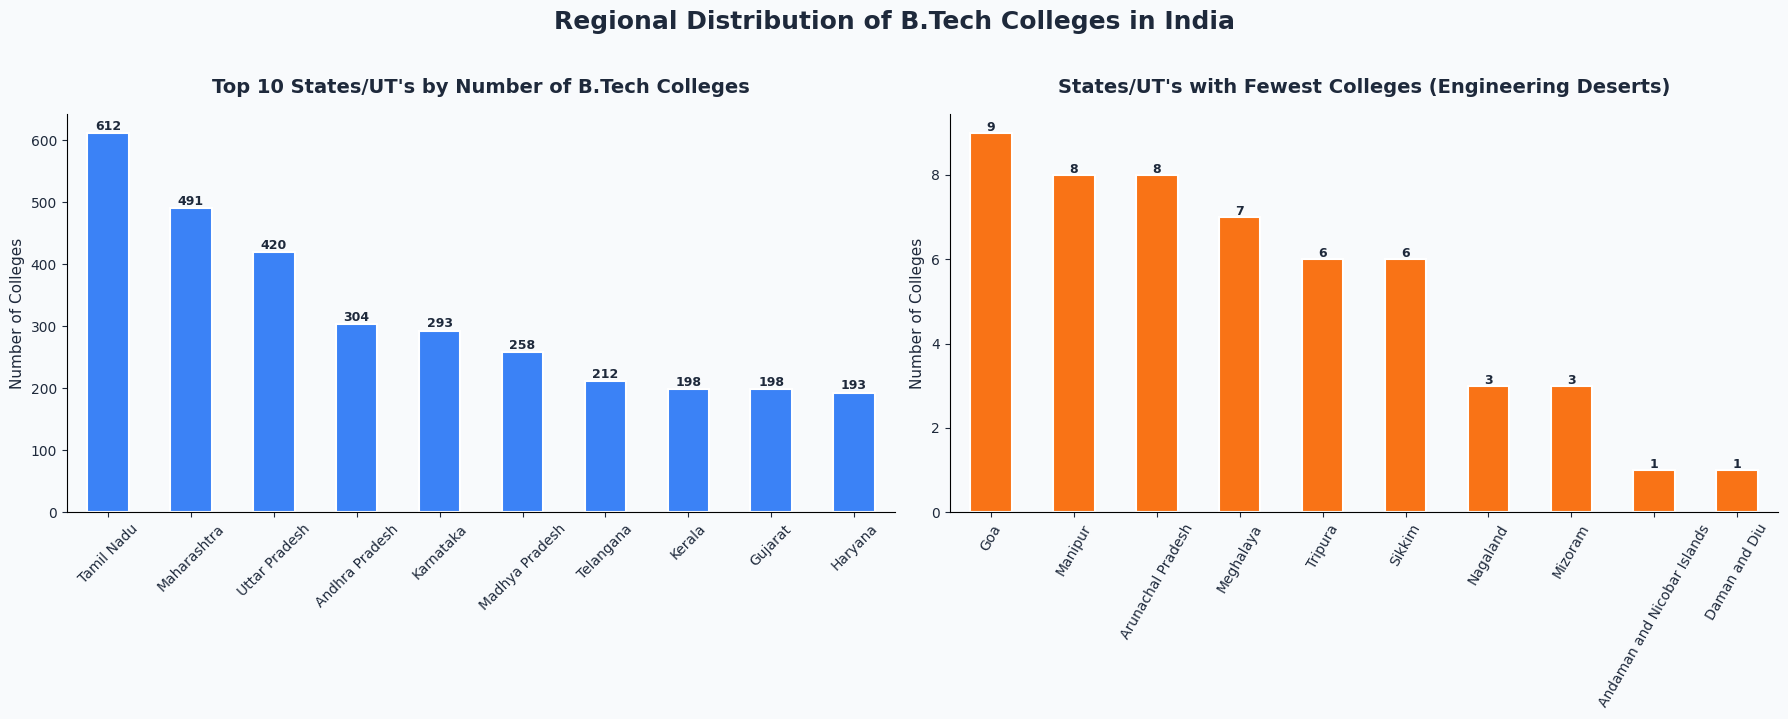

In [73]:
state_counts = df['State'].value_counts()

top_color = '#3B82F6'
bottom_color = '#F97316'
text_color = '#1E293B'
grid_color = '#CBD5E1'
bg_color = '#F8FAFC'

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(bg_color)

for ax in axes:
    ax.set_facecolor(bg_color)
    ax.grid(axis='y', linestyle='--', alpha=0.4, color=grid_color)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(colors=text_color)

# Top 10 States

state_counts.head(10).plot(
    kind='bar',
    ax=axes[0],
    color=top_color,
    edgecolor='white',
    linewidth=1.5
)

axes[0].set_title(
    'Top 10 States/UT\'s by Number of B.Tech Colleges',
    fontsize=14,
    fontweight='bold',
    color=text_color,
    pad=15
)

axes[0].set_xlabel(None, fontsize=11, color=text_color)
axes[0].set_ylabel('Number of Colleges', fontsize=11, color=text_color)
axes[0].tick_params(axis='x', rotation=45)

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height() + 5),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color=text_color
    )

# Bottom 10 States

state_counts.tail(10).plot(
    kind='bar',
    ax=axes[1],
    color=bottom_color,
    edgecolor='white',
    linewidth=1.5
)

axes[1].set_title(
    'States/UT\'s with Fewest Colleges (Engineering Deserts)',
    fontsize=14,
    fontweight='bold',
    color=text_color,
    pad=15
)

axes[1].set_xlabel(None, fontsize=11, color=text_color)
axes[1].set_ylabel('Number of Colleges', fontsize=11, color=text_color)
axes[1].tick_params(axis='x', rotation=60)


for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height() + 0.05),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color=text_color
    )


fig.suptitle(
    'Regional Distribution of B.Tech Colleges in India',
    fontsize=18,
    fontweight='bold',
    color=text_color,
    y=1.02
)

plt.tight_layout()
plt.show()

**Insight:** Tamil Nadu leads with 612 colleges — more than the bottom 12 states *combined*.


A student born in Nagaland (3 colleges), Mizoram (3), Andaman & Nicobar Islands (1) or Daman and Diu (1) has virtually no engineering options within their home state. They must relocate entirely — a financial and cultural barrier that students from Tamil Nadu or Maharashtra never face

#**1.2 — Top Cities for Engineering Education**

Which cities are the true hubs of engineering education? Where do opportunities physically concentrate?



In [74]:
df.groupby('State').size().reset_index(name='Total_Colleges')


,State,Total_Colleges
0,Andaman and Nicobar Islands,1
1,Andhra Pradesh,304
2,Arunachal Pradesh,8
3,Assam,24
4,Bihar,71
5,Chandigarh,13
6,Chhattisgarh,76
7,Daman and Diu,1
8,Delhi NCR,58
9,Goa,9


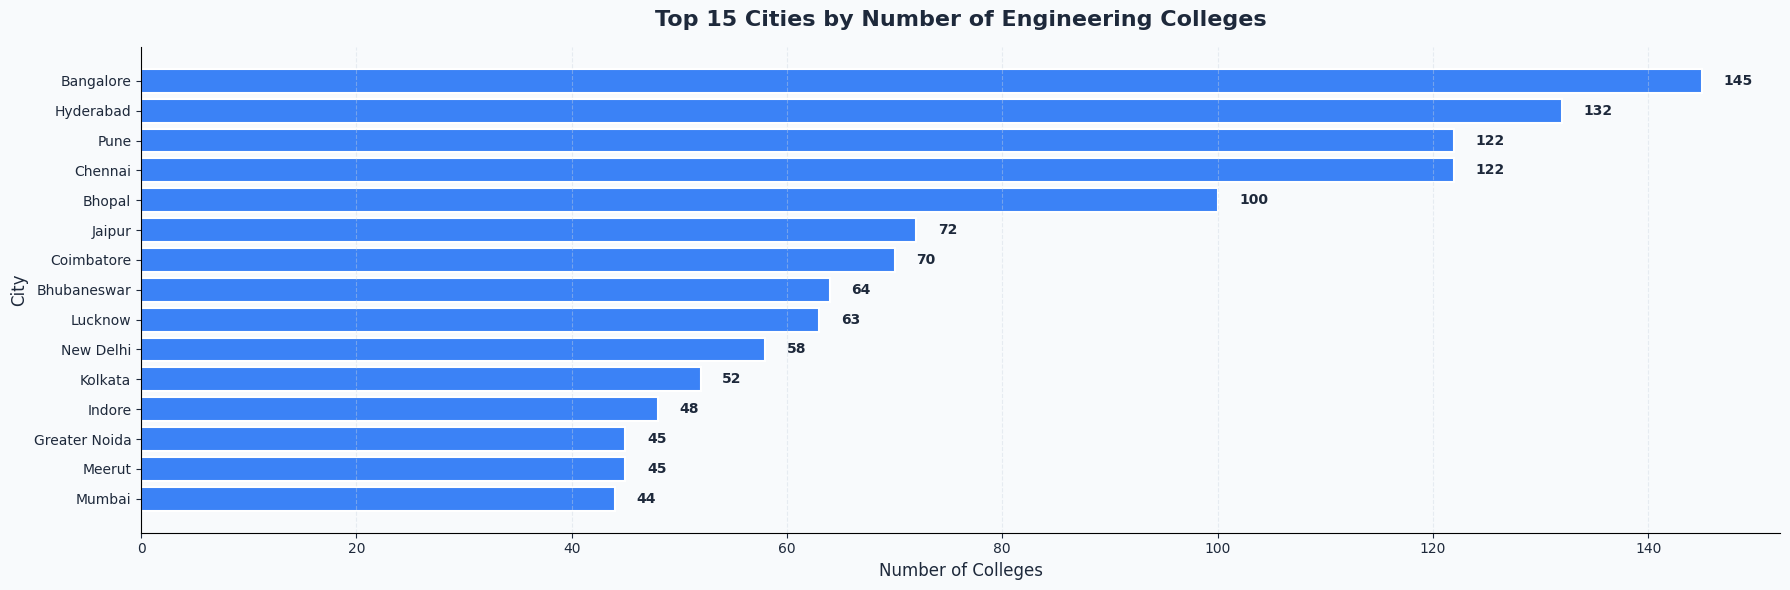

In [75]:
# Count colleges by city
city_counts = df['City'].value_counts().head(15)

# Theme Colors
bar_color = '#3B82F6'
bg_color = '#F8FAFC'
text_color = '#1E293B'
grid_color = '#CBD5E1'

# Create figure
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Plot
bars = ax.barh(
    city_counts.index,
    city_counts.values,
    color=bar_color,
    edgecolor='white',
    linewidth=1.5
)

# Highest city at top
ax.invert_yaxis()

# Titles and labels
ax.set_title(
    'Top 15 Cities by Number of Engineering Colleges',
    fontsize=16,
    fontweight='bold',
    color=text_color,
    pad=15
)

ax.set_xlabel(
    'Number of Colleges',
    fontsize=12,
    color=text_color
)

ax.set_ylabel(
    'City',
    fontsize=12,
    color=text_color
)

# Grid
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.4,
    color=grid_color
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tick styling
ax.tick_params(colors=text_color)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=text_color
    )

plt.tight_layout()
plt.show()

**Insight:** Engineering Education is Hyper-Urban

The top 15 cities account for a disproportionate share of all colleges. Bengaluru, Hyderabad, Pune and Chennai — all major IT hubs — dominate.

Students from Tier 2/3 towns don't just face fewer colleges — they face fewer colleges *in their future job markets*. Studying engineering in a smaller city often means weaker industry connections, fewer internship pipelines, and lower starting salaries.

#**1.3 — IIT , NIT and IIIT Distribution by State**

Question this answers:
Which states have premier institutions? Which states have been completely skipped in India's IIT/NIT expansion?


In [76]:
# ── Detection
df['Is_IIT'] = df["College Name"].str.match(
    r'^(IIT\s|ISM\s*Dhanbad)', case=False, na=False)

df['Is_NIT'] = (
    df['College Name'].str.match(r'^(NIT\s|MNNIT\s)', case=False, na=False) |
    df['College Name'].str.contains(
        r'\b(Visvesvaraya|Malaviya|Sardar Vallabhbhai|Maulana Azad|'
        r'Motilal Nehru National|Dr BR Ambedkar)\s+National Institute',
        case=False, na=False, regex=True) |
    df['College Name'].str.match(
        r'^National Institute of Technology\s*[-–\[]', case=False, na=False)
)

df['Is_IIIT'] = (
    df["College Name"].str.contains(
        r'\bIIIT\b|Indian Institute of Information Technology',
        case=False, na=False, regex=True)
    & ~df["College Name"].str.contains(
        r'International Institute|International Campus',
        case=False, na=False, regex=True)
)

# ── State-wise counts (unique by College Name + State)
iit_state  = (df[df['Is_IIT']].drop_duplicates(subset=['College Name','State'])
              .groupby('State').size().sort_values(ascending=False))

nit_state  = (df[df['Is_NIT']].drop_duplicates(subset=['College Name','State'])
              .groupby('State').size().sort_values(ascending=False))

iiit_state = (df[df['Is_IIIT']].drop_duplicates(subset=['College Name','City','State'])
              .groupby('State').size().sort_values(ascending=False))

print(f"IITs  : {iit_state.sum()} across {len(iit_state)} states")
print(f"NITs  : {nit_state.sum()} across {len(nit_state)} states")
print(f"IIITs : {iiit_state.sum()} across {len(iiit_state)} states")

IITs  : 23 across 22 states
NITs  : 31 across 31 states
IIITs : 25 across 17 states


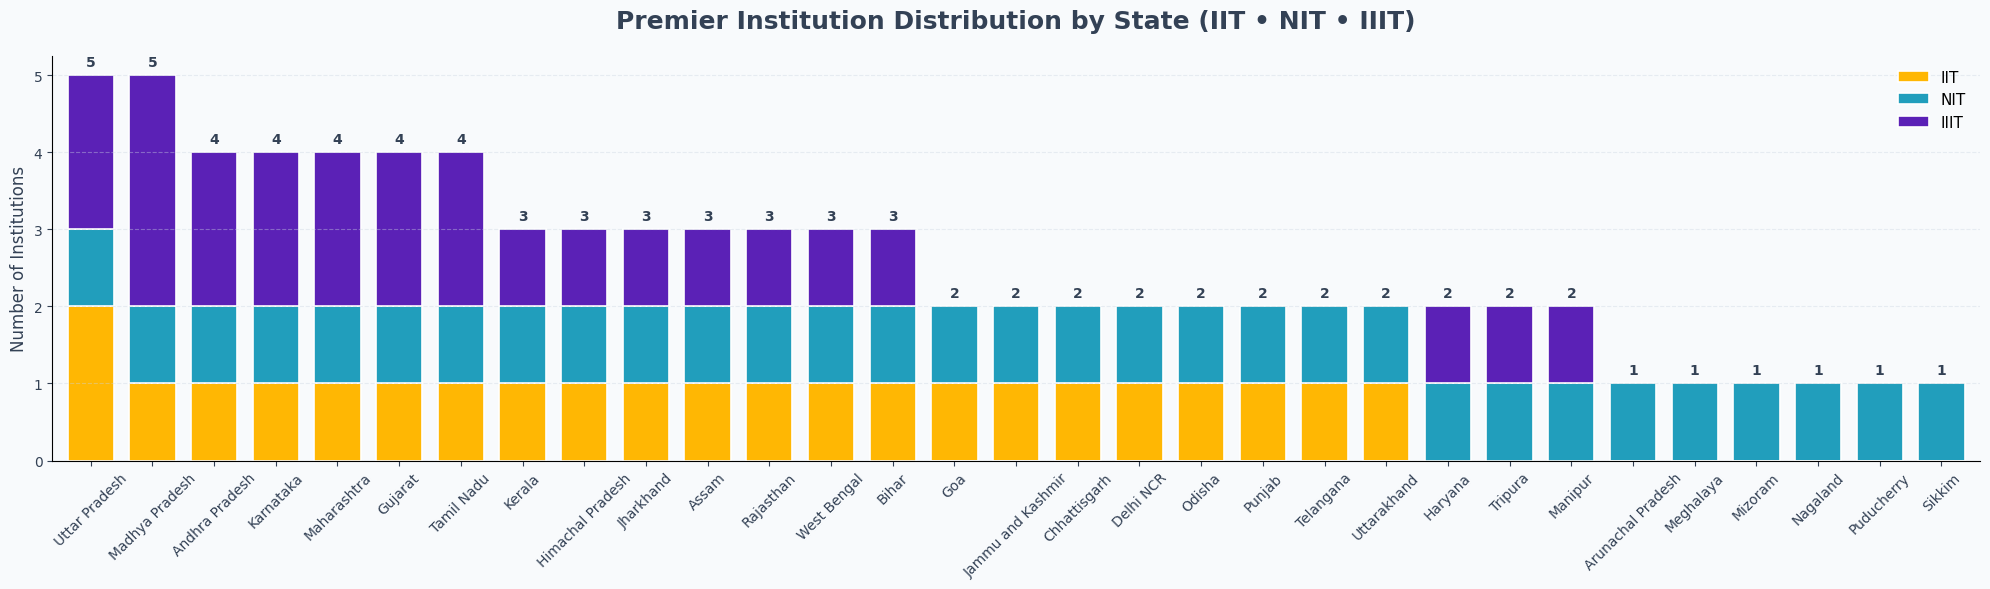


States with NO IIT, NIT or IIIT: 3
• Andaman and Nicobar Islands (1 colleges)
• Chandigarh (13 colleges)
• Daman and Diu (1 colleges)


In [77]:
# ── Create combined dataframe
elite_df = pd.concat([iit_state, nit_state, iiit_state], axis=1)
elite_df.columns = ['IIT', 'NIT', 'IIIT']
elite_df = elite_df.fillna(0)

# Sort states by total premier institutions
elite_df['Total'] = elite_df.sum(axis=1)
elite_df = elite_df.sort_values('Total', ascending=False)
elite_df.drop(columns='Total', inplace=True)

# ── Theme Colors
bg_color = '#F8FAFC'      # PPT Background
text_color = '#334155'    # Slate Gray
grid_color = '#CBD5E1'    # Light Gray

iit_color = '#FFB703'     # Golden Yellow
nit_color = '#219EBC'     # Cyan Blue
iiit_color = '#5B21B6'    # Violet

# ── Plot
fig, ax = plt.subplots(figsize=(20, 6))

# Background
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Stacked Bar Chart
elite_df.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.75,
    color=[iit_color, nit_color, iiit_color],
    edgecolor='white',
    linewidth=1.2
)

# Title
ax.set_title(
    'Premier Institution Distribution by State (IIT • NIT • IIIT)',
    fontsize=18,
    fontweight='bold',
    color=text_color,
    pad=20
)

# Labels
ax.set_xlabel('')
ax.set_ylabel(
    'Number of Institutions',
    fontsize=12,
    color=text_color
)

# Tick Formatting
ax.tick_params(
    axis='x',
    rotation=45,
    labelsize=10,
    colors=text_color
)

ax.tick_params(
    axis='y',
    labelsize=10,
    colors=text_color
)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4,
    color=grid_color
)

# Remove Extra Borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(
    title='',
    fontsize=11,
    frameon=False,
    loc='upper right'
)

# Add Total Labels Above Bars
totals = elite_df.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 0.08,
        str(int(total)),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=text_color
    )

plt.tight_layout()
plt.show()

# ── States with ZERO Premier Institutions ────────────────────
all_states = set(df['State'].unique())
elite_states = (
    set(iit_state.index)
    | set(nit_state.index)
    | set(iiit_state.index)
)

no_elite = sorted(all_states - elite_states)

print(f"\nStates with NO IIT, NIT or IIIT: {len(no_elite)}")

for state in no_elite:
    print(f"• {state} ({state_counts.get(state, 0)} colleges)")

Insight: **The Numbers:**
- 22 states have BOTH an IIT and NIT — solid coverage
- 9 states have NIT Only (Manipur, Meghalaya, Mizoram, Nagaland,
  Puducherry, Haryana, Sikkim, Arunachal Pradesh, Tripura)
- 0 states have IIT Only
- 5 territories have NEITHER — Daman & Diu (1 college),
  Andaman & Nicobar Islands (1 college), Chandigarh (13 colleges), Ladakh (0 colleges), Lakshadweep (0 colleges)

The Government's NIT expansion successfully placed one NIT
in almost every state — including small Northeast states like Mizoram,
Nagaland, and Sikkim. This is a genuine policy success story.

However, 9 states still lack an IIT. These are mostly smaller states
where the NIT serves as the only premier option. For students in these
states, getting into an IIT means leaving home entirely.

# **Quality — Accreditation, Ratings & Recognition**

**2.1 — Accreditation Coverage by State**

Question this answers:
What percentage of colleges in each state are AICTE approved? Which states have the most unregulated institutions?


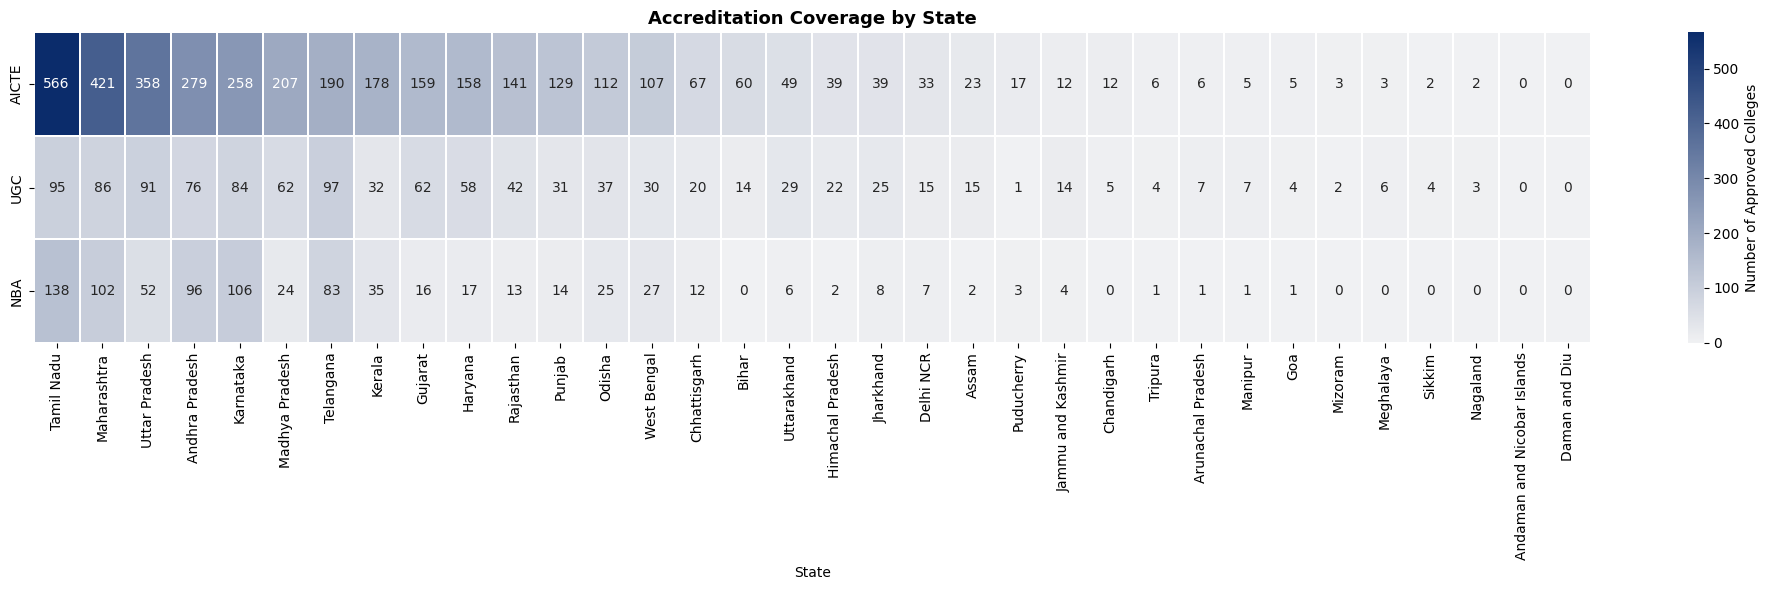

In [78]:
# Fix conversion first
df['AICTE_Approval']   = df['AICTE_Approval'].map({'Yes':1,'No':0,'Exempt':1}).fillna(0)
df['UGC_Recognition']  = df['UGC_Recognition'].map({'Yes':1,'No':0,'Exempt':1}).fillna(0)
df['NBA_Accreditation']= df['NBA_Accreditation'].map({'Yes':1,'No':0}).fillna(0)

# Now rebuild accreditation summary
state_total = df.groupby('State').size().rename('Total')
state_aicte = df[df['AICTE_Approval']==1].groupby('State').size().rename('AICTE')
state_nba   = df[df['NBA_Accreditation']==1].groupby('State').size().rename('NBA')
state_ugc   = df[df['UGC_Recognition']==1].groupby('State').size().rename('UGC')

accred = pd.concat([state_total, state_aicte, state_nba, state_ugc], axis=1).fillna(0)

plt.figure(figsize=(20, 6))
sns.heatmap(accred[['AICTE','UGC','NBA']].sort_values('AICTE', ascending=False).T,
    annot=True, fmt='.0f', cmap=sns.light_palette("#0B2C6B", as_cmap=True), linewidths=0.3,
    cbar_kws={'label': 'Number of Approved Colleges'})
plt.title('Accreditation Coverage by State', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

📊 Finding 2.1 — Accreditation Gaps Expose Paper Colleges
Tamil Nadu and Maharashtra lead in raw accreditation numbers — but some states have large numbers of colleges where a significant share are not AICTE approved, operating in a regulatory gray zone.

For a student or parent: An AICTE-unapproved college cannot participate in central government scholarships, and degrees from such colleges may not be recognised by certain state PSUs and government employers. This is not a minor detail — it materially affects a graduate's career options.

**2.2 — Student Ratings by State**

Question this answers:
Based on student reviews, which states consistently have highly-rated colleges? Which have the worst-rated institutions?


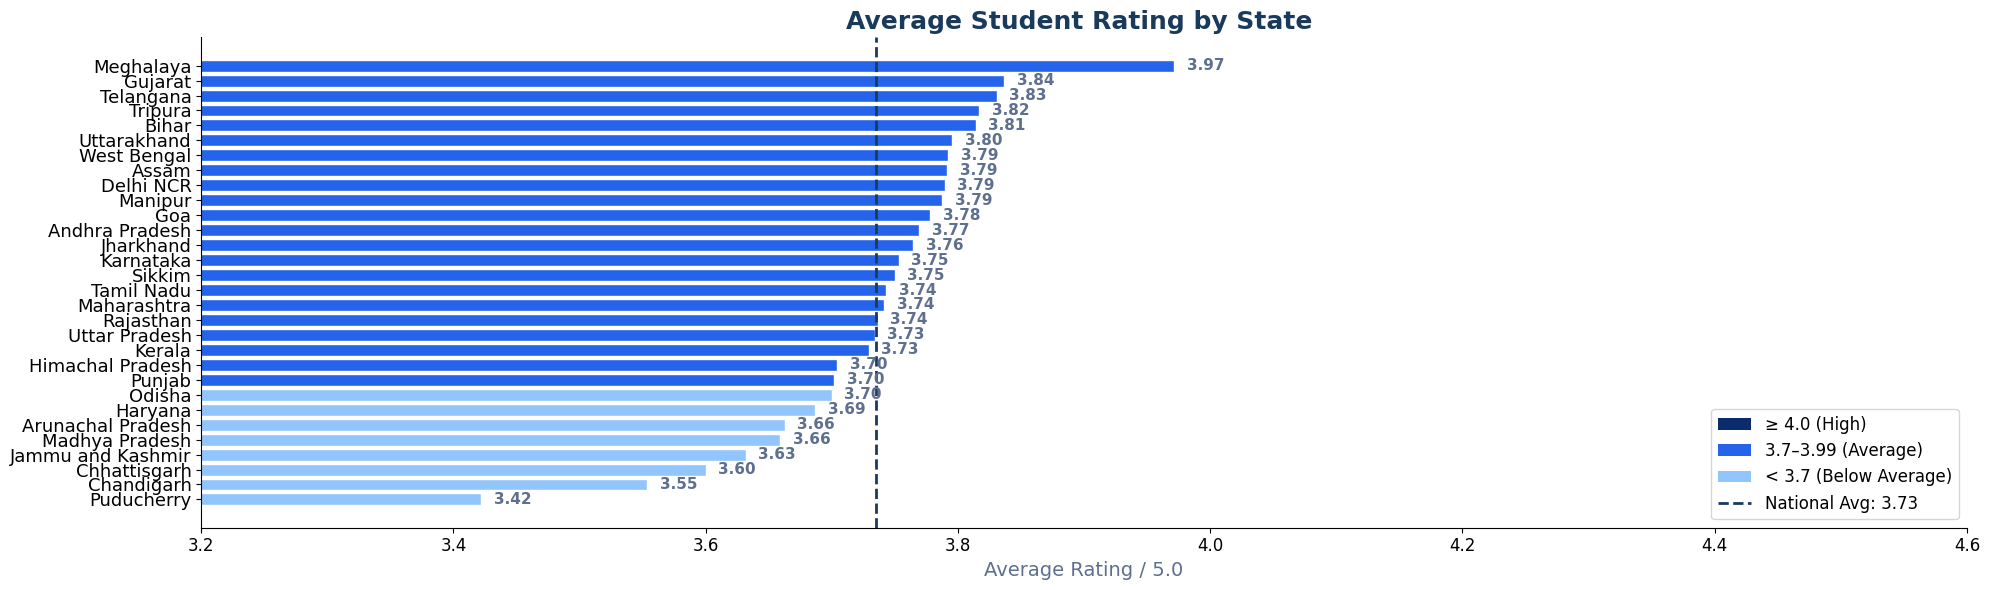

National average rating: 3.73
States ABOVE 4.0: 0
States BETWEEN 3.7 and 4.0: 22
States BELOW 3.7: 8


In [79]:

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Average Rating by State ─────────────────────────────
state_rating = (
    df.groupby('State')['Rating']
    .agg(['mean', 'count'])
    .reset_index()
)

state_rating.columns = ['State', 'Avg_Rating', 'College_Count']

# Keep states with at least 5 colleges
state_rating = (
    state_rating[state_rating['College_Count'] >= 5]
    .sort_values('Avg_Rating', ascending=False)
)

# National average
national_avg = state_rating['Avg_Rating'].mean()

# ── Colors (Blue Theme) ─────────────────────────────
colors = [
    '#0B2C6B' if r >= 4.0      # Dark Navy Blue
    else '#2563EB' if r >= 3.7 # Royal Blue
    else '#93C5FD'             # Light Blue
    for r in state_rating['Avg_Rating']
]

# ── Plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))

bars = ax.barh(
    state_rating['State'],
    state_rating['Avg_Rating'],
    color=colors,
    edgecolor='white'
)

# Highest state on top
ax.invert_yaxis()

# National average line
ax.axvline(
    x=national_avg,
    color='#1A3A5C',
    linestyle='--',
    linewidth=2
)

# Value labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=11,
        color='#5E708E',
        fontweight='bold'
    )

# Title
ax.set_title(
    'Average Student Rating by State ',
    fontsize=18,
    fontweight='bold',
    color='#1A3A5C'
)

# Axis labels
ax.set_xlabel(
    'Average Rating / 5.0',
    fontsize=14,
    color='#5E708E'
)
ax.set_ylabel('')

# Axis limits
ax.set_xlim(3.2, 4.6)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tick sizes
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=13)

# Legend
legend_elements = [
    Patch(facecolor='#0B2C6B', label='≥ 4.0 (High)'),
    Patch(facecolor='#2563EB', label='3.7–3.99 (Average)'),
    Patch(facecolor='#93C5FD', label='< 3.7 (Below Average)'),
    Line2D(
        [0], [0],
        color='#1A3A5C',
        linestyle='--',
        linewidth=2,
        label=f'National Avg: {national_avg:.2f}'
    )
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────
print(f"National average rating: {national_avg:.2f}")
print(f"States ABOVE 4.0: {(state_rating['Avg_Rating'] >= 4.0).sum()}")
print(f"States BETWEEN 3.7 and 4.0: {((state_rating['Avg_Rating'] >= 3.7) & (state_rating['Avg_Rating'] < 4.0)).sum()}")
print(f"States BELOW 3.7: {(state_rating['Avg_Rating'] < 3.7).sum()}")

📊 Finding 2.2 — Student Ratings Tell a Different Story Than Accreditation
Some states have high accreditation rates but below-average student ratings — meaning students who attend colleges there are not satisfied despite official approval.

The national average rating sits around 3.7/5.0. States below 3.5 have colleges that students themselves do not recommend. This is an important quality signal that official approval statistics alone cannot capture.

# **Course Diversity — What's Being Taught Where**

**The Core Question:** Can students study what they *want* — or are they forced into whatever their home state happens to offer?

**Most and Least Offered Branches Nationally**

What branches dominate India's engineering landscape? What is rare or nearly absent?

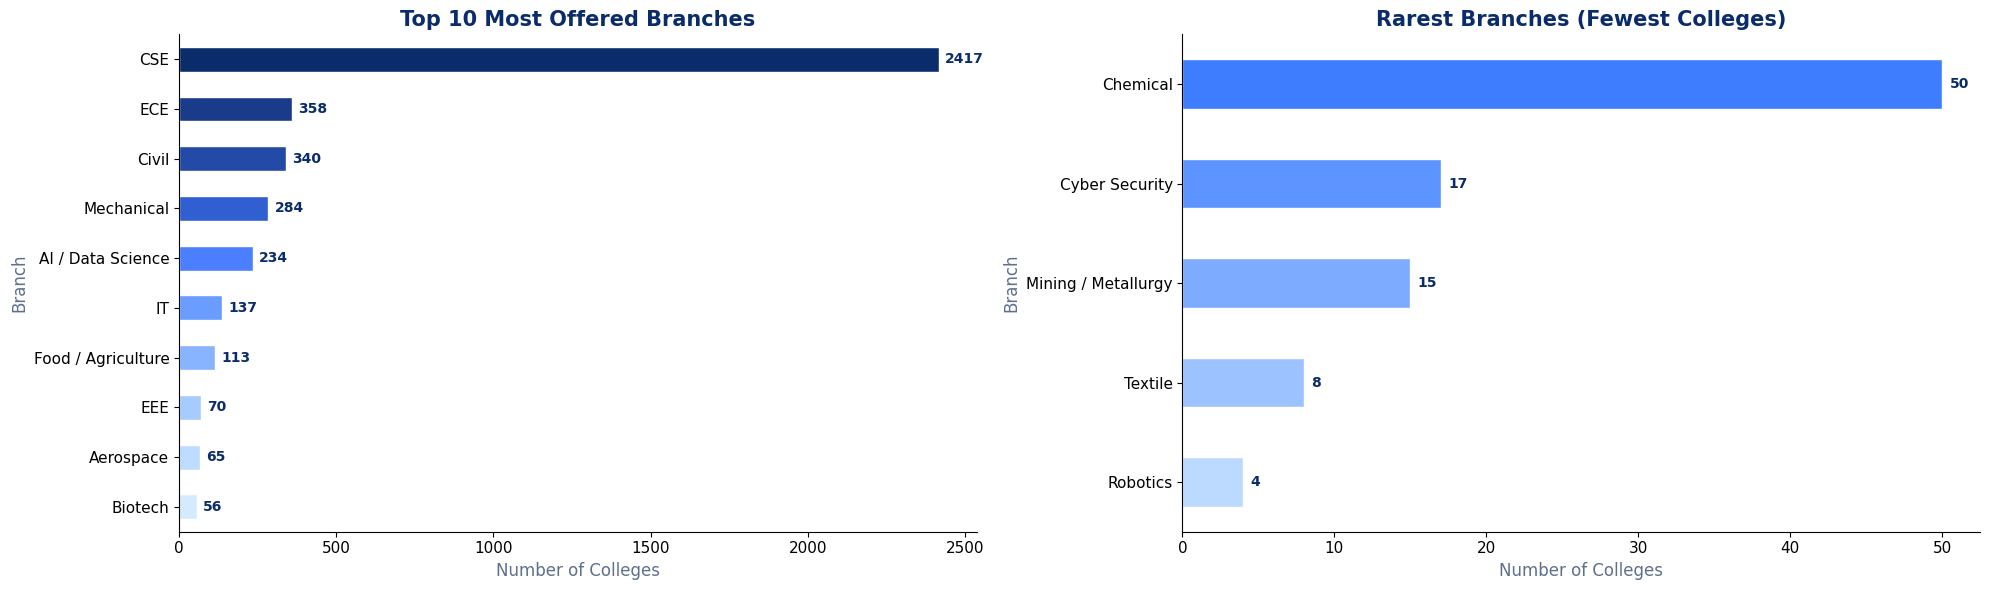

In [80]:
# Count branches
branch_counts = df['Branch'].value_counts()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ── Colors ─────────────────────────────────────────────
top_colors = [
    '#0B2C6B',
    '#1A3A8A',
    '#234AA6',
    '#2F5FD0',
    '#4C7FFF',
    '#6B9CFF',
    '#88B4FF',
    '#A5CBFF',
    '#BEDCFF',
    '#D6EAFF'
]

rare_colors = [
    '#3F7DFF',
    '#5E94FF',
    '#7DABFF',
    '#9CC2FF',
    '#BCD9FF'
]

# ── Top 10 Most Offered Branches ──────────────────────
branch_counts.head(10).plot(
    kind='barh',
    ax=axes[0],
    color=top_colors,
    edgecolor='white'
)

axes[0].invert_yaxis()

axes[0].set_title(
    'Top 10 Most Offered Branches',
    fontsize=15,
    fontweight='bold',
    color='#0B2C6B'
)

axes[0].set_xlabel(
    'Number of Colleges',
    fontsize=12,
    color='#5E708E'
)

axes[0].set_ylabel(
    'Branch',
    fontsize=12,
    color='#5E708E'
)

axes[0].tick_params(axis='both', labelsize=11)

# Add values
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_width())),
        (p.get_width() + 20, p.get_y() + p.get_height()/2),
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#0B2C6B'
    )

# Remove top and right borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Rarest Branches ───────────────────────────────────
rare = branch_counts[
    ~branch_counts.index.isin(['Unknown', 'Other'])
].tail(5)

rare.plot(
    kind='barh',
    ax=axes[1],
    color=rare_colors,
    edgecolor='white'
)

axes[1].invert_yaxis()

axes[1].set_title(
    'Rarest Branches (Fewest Colleges)',
    fontsize=15,
    fontweight='bold',
    color='#0B2C6B'
)

axes[1].set_xlabel(
    'Number of Colleges',
    fontsize=12,
    color='#5E708E'
)

axes[1].set_ylabel(
    'Branch',
    fontsize=12,
    color='#5E708E'
)

axes[1].tick_params(axis='both', labelsize=11)

# Add values
for p in axes[1].patches:
    axes[1].annotate(
        str(int(p.get_width())),
        (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#0B2C6B'
    )

# Remove top and right borders
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Remove grids
axes[0].grid(False)
axes[1].grid(False)

plt.tight_layout()
plt.show()

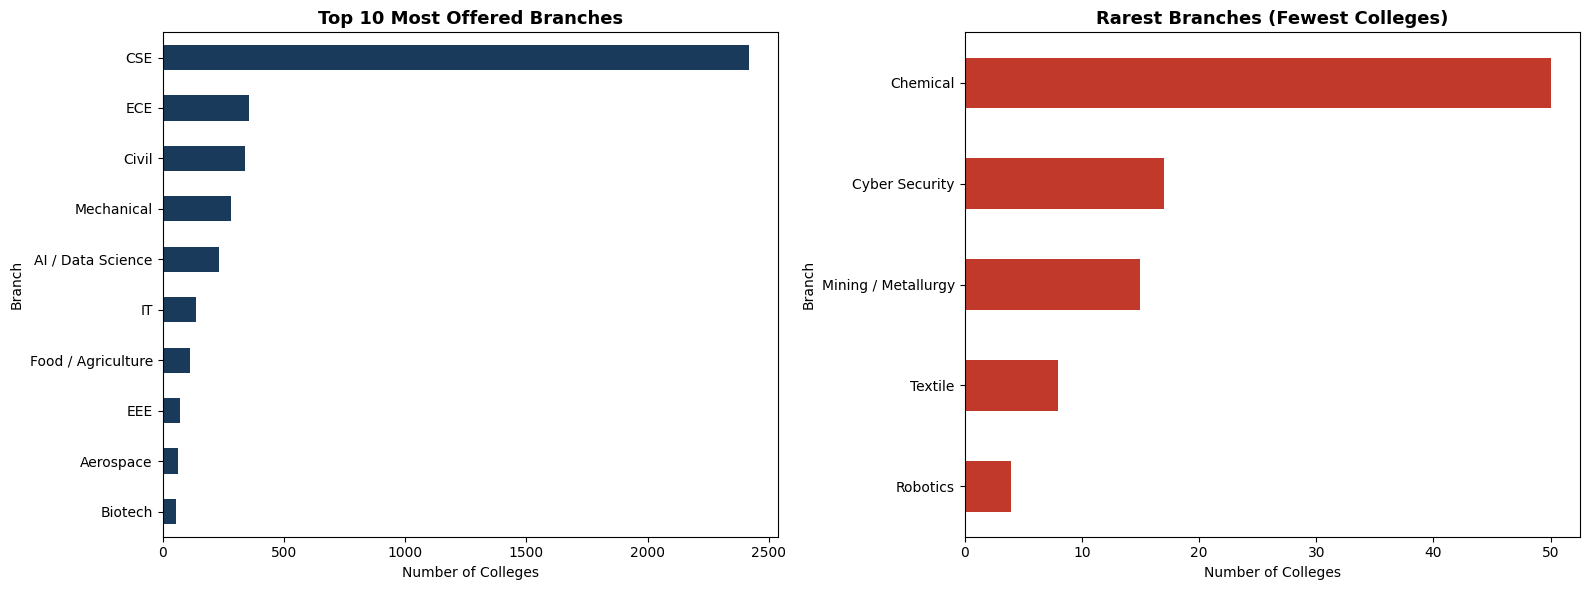

In [81]:
branch_counts = df['Branch'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most offered
branch_counts.head(10).plot(kind='barh', ax=axes[0], color='#1A3A5C')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Most Offered Branches', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Colleges')

# Rarest branches (exclude 'Unknown' and 'Other')
rare = branch_counts[~branch_counts.index.isin(['Unknown','Other'])].tail(5)
rare.plot(kind='barh', ax=axes[1], color='#C0392B')
axes[1].invert_yaxis()
axes[1].set_title('Rarest Branches (Fewest Colleges)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Colleges')

plt.tight_layout(); plt.show()


## 📊 Finding 3.1 — India's Engineering Education Has a CSE Monoculture Problem

**CSE dominates with 2,417 colleges — 57% of ALL engineering offerings in India.**
The next closest branch (ECE) has just 358 colleges — nearly 7x fewer.

### The Demand-Supply Mismatch:

| Sector | Colleges | Reality |
|---|---|---|
| Software (CSE+IT) | 2,554 | Oversupplied — lakhs of CSE graduates compete for same jobs |
| Core Engineering (Civil+Mechanical+EEE) | 694 | Infrastructure sector starved of fresh talent |
| Future Tech (AI+Cyber+Robotics) | 255 | Growing fastest in job market, least represented |
| Niche/Strategic (Aerospace+Textile+Mining) | 77 | Critical industries, almost invisible in education |

### The Starkest Numbers:
- India has **604x more CSE colleges than Robotics colleges** (2417 vs 4)
- **Textile industry** employs 45 million Indians — yet only **8 colleges** offer Textile Engineering
- **Aerospace** is a ₹70,000 crore sector — yet only **65 colleges** train aerospace engineers
- **Cyber Security** is the fastest growing tech field — yet only **17 colleges** offer it as a branch

> India is mass-producing one type of engineer while simultaneously
> struggling to find trained talent in Aerospace, Cybersecurity, Textiles,
> and Mining — sectors that are critical to its economic future.
> This is not a market failure. It is a curriculum planning failure.



**3.2 — The Branch-by-State Heatmap (Hero Chart)**

Which branches are available in which states? Where are the course deserts?


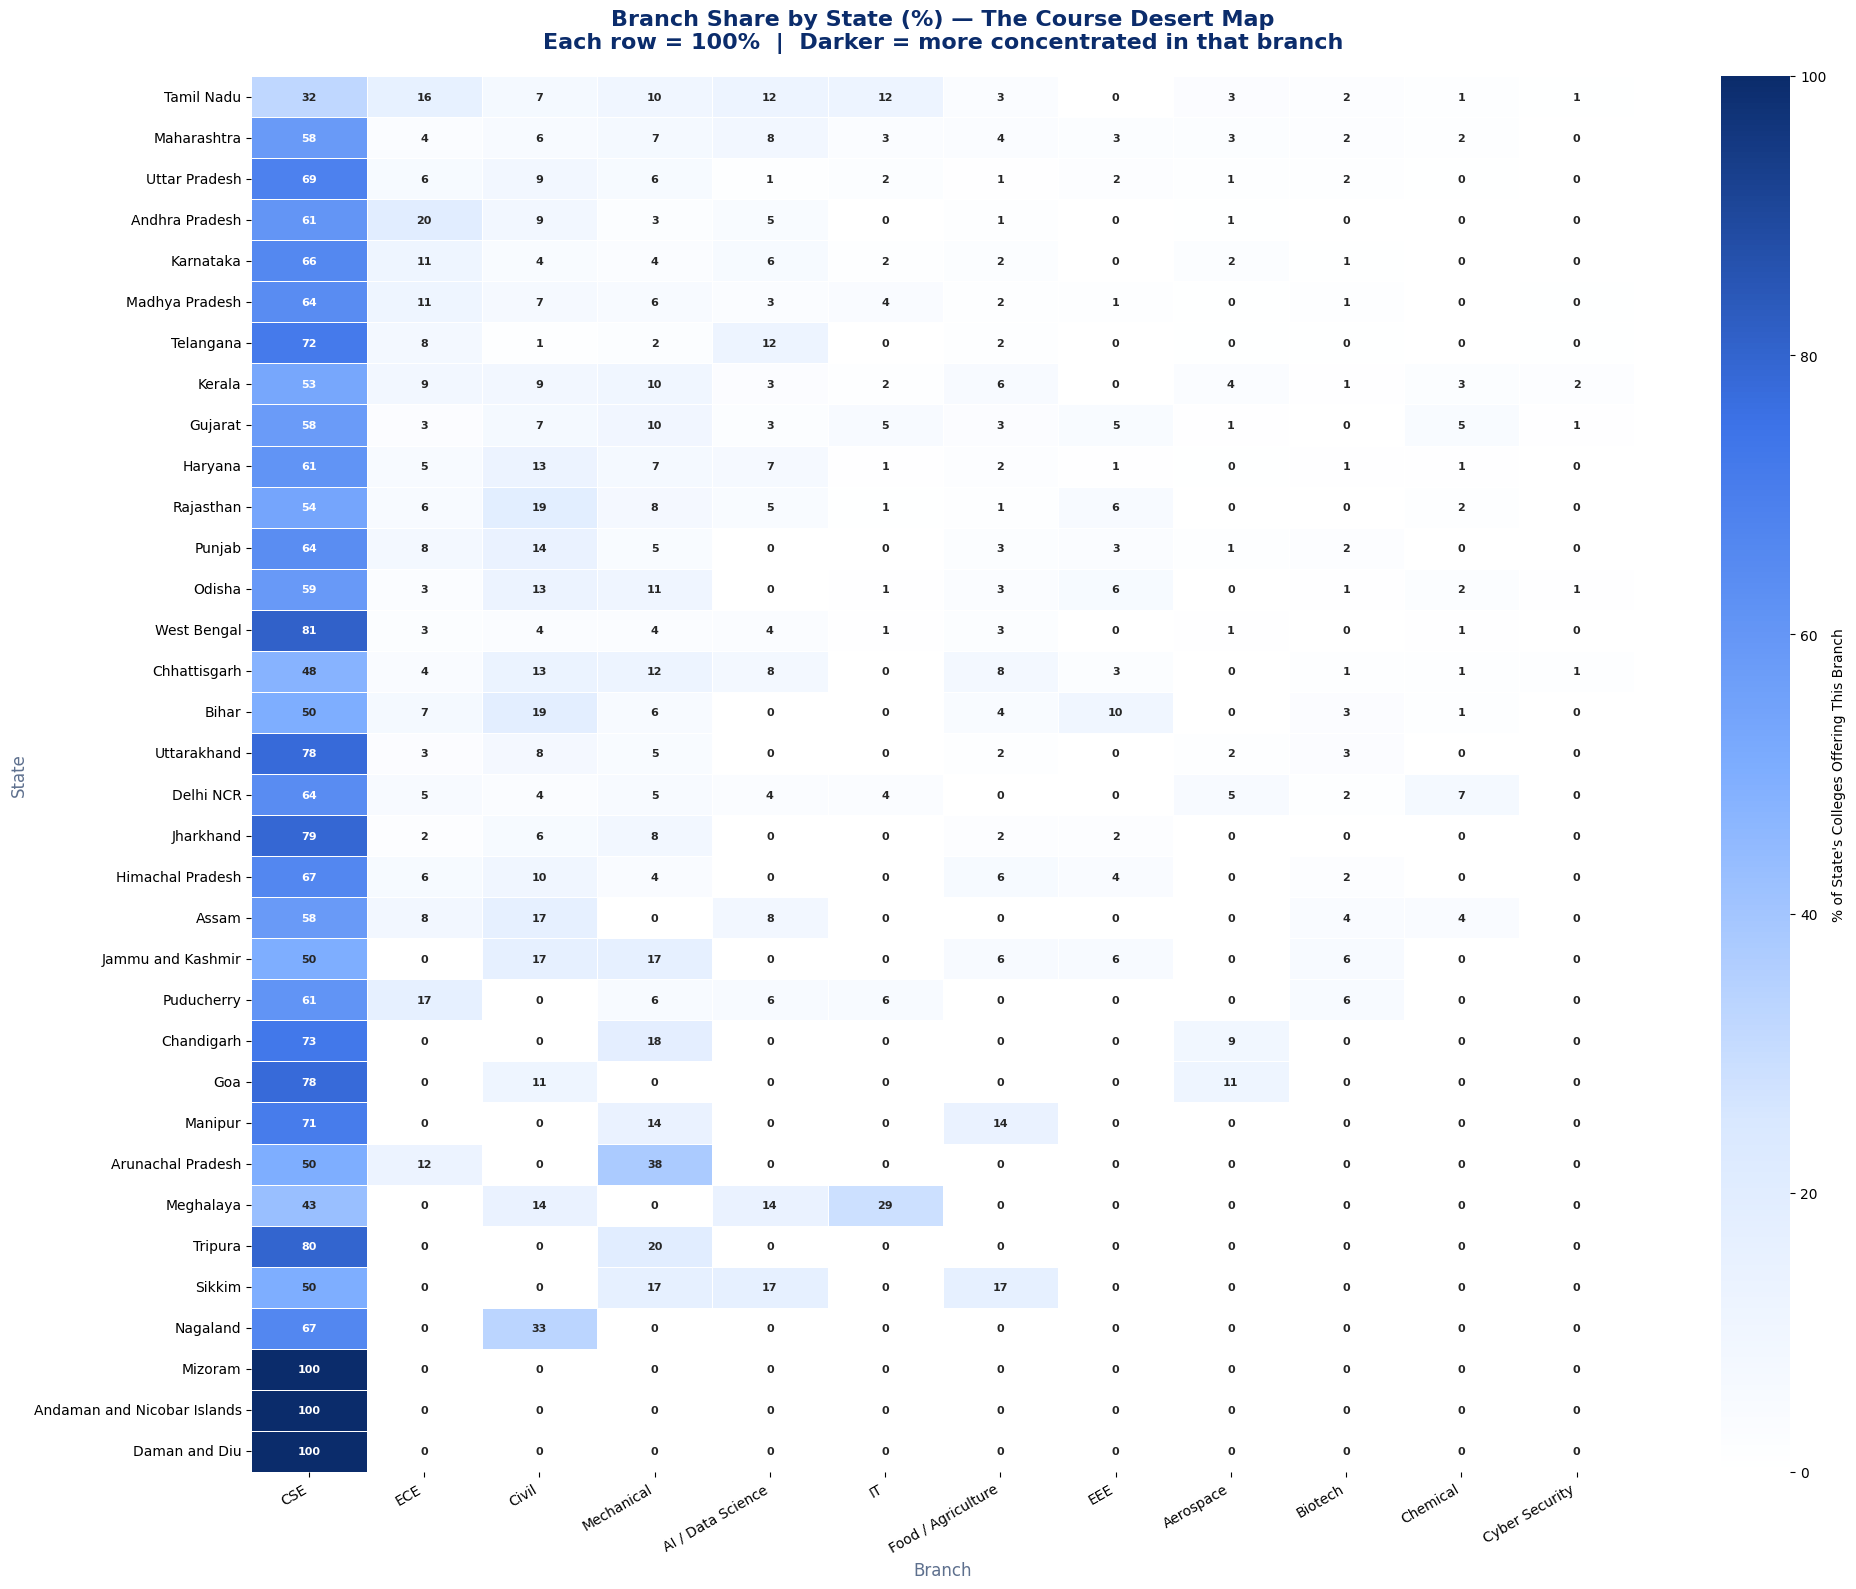

In [82]:
from matplotlib.colors import LinearSegmentedColormap

# Step 1 — Build branch × state matrix

branch_state = df.groupby(['State', 'Branch']).size().unstack(fill_value=0)

# Top 12 branches (excluding Unknown and Other)
branch_counts = df['Branch'].value_counts()

top_branches = branch_counts[
    ~branch_counts.index.isin(['Unknown', 'Other'])
].head(12).index

branch_state_top = branch_state.reindex(columns=top_branches, fill_value=0)

branch_state_top = branch_state_top.loc[
    df['State'].value_counts().index.intersection(branch_state_top.index)
]


# Step 2 — Convert to row percentages

branch_state_pct = (
    branch_state_top
    .div(branch_state_top.sum(axis=1), axis=0)
    * 100
).round(1)


# Step 3 — Create PPT-style blue colormap

ppt_blue = LinearSegmentedColormap.from_list(
    "ppt_blue",
    [
        "#FFFFFF",   # very light
        "#D9E8FF",   # light blue
        "#7FAEFF",   # medium blue
        "#3D73E8",   # royal blue
        "#0B2C6B"    # dark navy
    ]
)


# Step 4 — Plot heatmap

plt.figure(figsize=(20, 16))

sns.heatmap(
    branch_state_pct,
    cmap=ppt_blue,
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={
        'fontsize':8,
        'fontweight':'bold'
    },
    cbar_kws={
        'label': "% of State's Colleges Offering This Branch"
    },
    vmin=0,
    vmax=100
)


# Formatting

plt.title(
    'Branch Share by State (%) — The Course Desert Map\n'
    'Each row = 100%  |  Darker = more concentrated in that branch',
    fontsize=16,
    fontweight='bold',
    color='#0B2C6B',
    pad=20
)

plt.xlabel(
    'Branch',
    fontsize=12,
    color='#5E708E'
)

plt.ylabel(
    'State',
    fontsize=12,
    color='#5E708E'
)

plt.xticks(
    rotation=30,
    ha='right',
    fontsize=10
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

## 📊 Finding 3.2 — The Course Desert Map: What Each State Actually Offers

### The CSE Monopoly States (CSE > 70%)
| State | CSE % | Reality |
|---|---|---|
| Mizoram | 100% | Only CSE — zero other branches |
| Andaman & Nicobar | 100% | Only CSE — zero other branches |
| Daman & Diu | 100% | Only CSE — zero other branches |
| Tripura | 80% | 4 colleges, 3 are pure CSE |
| West Bengal | 81% | 115 colleges but heavily CSE-skewed |
| Uttarakhand | 78% | 64 colleges, almost all CSE |
| Jharkhand | 79% | CSE + minimal Civil only |
| Goa | 78% | CSE dominant, 11% Aerospace surprising |
| Telangana | 72% | Despite being a tech hub, 72% CSE |

### The Most Diverse States (Healthy Spread)
| State | Why It Stands Out |
|---|---|
| Tamil Nadu | Most balanced — CSE 32%, ECE 16%, AI 12%, IT 12% |
| Kerala | Strong in Food/Agriculture (6%), Biotech (3%), Cyber Security (2%) |
| Gujarat | Only state with significant EEE (5%) + Chemical (5%) |
| Rajasthan | Highest Civil % (19%) — reflects construction sector demand |

### Surprising Hidden Patterns
- **Arunachal Pradesh** has 38% Mechanical — highest in any state,
  likely driven by border infrastructure needs
- **Goa** has 11% Aerospace — surprising for a small state,
  likely due to defence/naval presence
- **Bihar** has 10% EEE — one of the highest, but zero AI/ML
- **Chandigarh** has 9% Aerospace and 7% Chemical —
  most diverse small territory in India
- **Meghalaya** has 29% IT — second highest after Tamil Nadu's 12%
- **Manipur** has 14% Food/Agriculture — reflects its agricultural economy
- **Jammu & Kashmir** has 17% Civil + 17% Mechanical —
  infrastructure-focused, zero AI/ML

### The Zeros Tell the Real Story
- **AI / Data Science = 0** in: West Bengal, Bihar, Jharkhand,
  Uttarakhand, Assam, J&K, Manipur, Arunachal, Tripura,
  Nagaland, Mizoram, Andaman, Daman & Diu
- **Cyber Security = 0** in 25 out of 34 states
- **Chemical Engineering = 0** in 20+ states despite
  India being a major chemicals manufacturer

> The percentage view reveals what raw numbers hide —
> it's not just about HOW MANY colleges a state has,
> but WHETHER those colleges offer any real choice.
> A student in Mizoram, Tripura, or Andaman has
> exactly ONE path: Computer Science.
> Everything else requires leaving home.

**3.3 — Future-Tech Access: AI/ML, Data Science, Cyber Security**

Which states offer emerging tech branches? Are students in certain states locked out of the future of engineering?

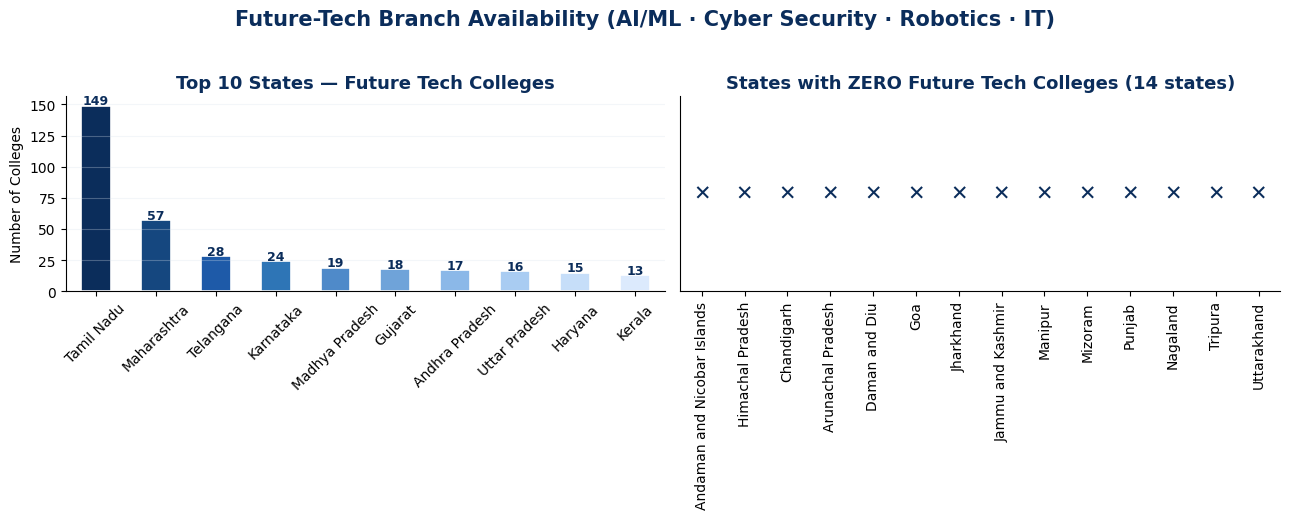

In [83]:
# Future Tech Branches

future_tech = ['AI / Data Science', 'Cyber Security', 'Robotics', 'IT']

state_future = branch_state.reindex(columns=future_tech, fill_value=0)
state_future['Future_Tech_Total'] = state_future.sum(axis=1)
state_future = state_future.sort_values('Future_Tech_Total', ascending=False)

top10 = state_future[state_future['Future_Tech_Total'] > 0].head(10)['Future_Tech_Total']
zero = state_future[state_future['Future_Tech_Total'] == 0]['Future_Tech_Total']

# Theme Colors

blue_colors = [
    '#0B2D5B',
    '#15477F',
    '#1E5AA8',
    '#2E75B6',
    '#4F8AC9',
    '#6FA3D9',
    '#8BB8E8',
    '#A9CCF2',
    '#C6DEF9',
    '#DCEAFD'
]

orange = '#F39C12'
navy = '#0B2D5B'
grid_color = '#D9E2EC'


# Figure

fig, axes = plt.subplots(1, 2, figsize=(13,5))


# LEFT: Top 10 States

bars = top10.plot(
    kind='bar',
    ax=axes[0],
    color=blue_colors,
    edgecolor='white',
    linewidth=1.2
)

axes[0].set_title(
    'Top 10 States — Future Tech Colleges',
    fontsize=13,
    fontweight='bold',
    color=navy
)

axes[0].set_ylabel('Number of Colleges')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3, color=grid_color)

# Value labels
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()+1),
        ha='center',
        fontsize=9,
        color=navy,
        fontweight='bold'
    )

# Remove top/right borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# RIGHT: Zero Future-Tech States

bars2 = zero.plot(
    kind='bar',
    ax=axes[1],
    color=orange,
    edgecolor='white',
    linewidth=1.2
)

axes[1].set_title(
    f'States with ZERO Future Tech Colleges ({len(zero)} states)',
    fontsize=13,
    fontweight='bold',
    color=navy
)

axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylim(0,1)
axes[1].set_yticks([])
axes[1].tick_params(axis='x', rotation=90)

# X marks inside bars
for i in range(len(zero)):
    axes[1].text(
        i,
        0.5,
        '✕',
        ha='center',
        va='center',
        fontsize=15,
        color=navy,
        fontweight='bold'
    )

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Light grid
axes[1].grid(axis='y', alpha=0.2, color=grid_color)


# Main Title

plt.suptitle(
    'Future-Tech Branch Availability (AI/ML · Cyber Security · Robotics · IT)',
    fontsize=15,
    fontweight='bold',
    color=navy,
    y=1.03
)

plt.tight_layout()
plt.show()

## 📊 Finding 3.3 — The Future-Tech Divide: 14 States Left Behind

**Top 10 states dominate future-tech completely:**
| State | Future-Tech Colleges |
|---|---|
| Tamil Nadu | 149 |
| Maharashtra | 57 |
| Telangana | 28 |
| Karnataka | 24 |
| Madhya Pradesh | 19 |
| Gujarat | 18 |
| Andhra Pradesh | 17 |
| Uttar Pradesh | 16 |
| Haryana | 15 |
| Kerala | 13 |

**14 states have ZERO future-tech colleges:**
Andaman & Nicobar, Himachal Pradesh, Chandigarh,
Arunachal Pradesh, Daman & Diu, Goa, Jharkhand,
Jammu & Kashmir, Manipur, Mizoram, Punjab,
Nagaland, Tripura, Uttarakhand

> **The core finding:** Future-tech education is
> concentrated in 4–5 southern and western states.
> Tamil Nadu alone (149) has more future-tech colleges
> than the remaining 9 states in the top 10 combined (207 —
> close but Tamil Nadu leads by a wide margin).
>
> A student in Jharkhand, Punjab, or Uttarakhand —
> states with 51, 150, and 64 colleges respectively —
> has **zero options** for AI/ML, Cyber Security,
> Robotics or IT within their home state.
> They must relocate entirely just to access
> the most in-demand fields of the next decade.
>
> This is not a small state problem — **Punjab has
> 150 colleges and zero future-tech offerings.**
> That is a policy failure, not a size constraint.

**3.4 — Course Monopoly: States Dominated by One Branch**

Are there states where one branch (usually CSE) takes up more than 60% of all seats — leaving students with almost no real choice?

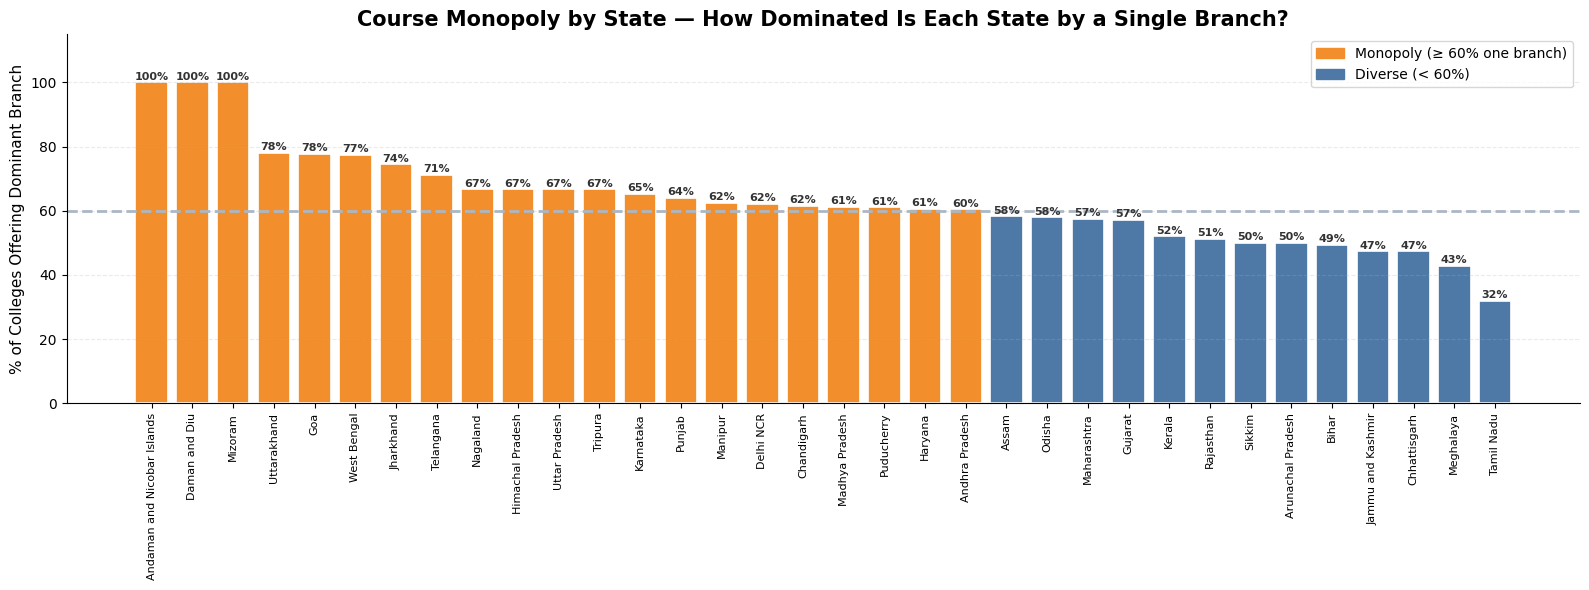

In [84]:
# Build Monopoly Table

branch_state = df.groupby(['State', 'Branch']).size().unstack(fill_value=0)

branch_state_pct = branch_state.div(
    branch_state.sum(axis=1),
    axis=0
) * 100

dominant_branch = branch_state_pct.idxmax(axis=1)
dominant_pct = branch_state_pct.max(axis=1)

monopoly = pd.DataFrame({
    'Dominant_Branch': dominant_branch,
    'Share_%': dominant_pct.round(1)
}).sort_values('Share_%', ascending=False)

# Theme Colors

monopoly_color = '#F28E2B'   # Coral Orange
diverse_color = '#4E79A7'    # Steel Blue
threshold_color = '#AAB7C4'  # Light Gray

colors = [
    monopoly_color if v >= 60 else diverse_color
    for v in monopoly['Share_%']
]

# Plot

fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(
    monopoly.index,
    monopoly['Share_%'],
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

# 60% threshold
ax.axhline(
    y=60,
    color=threshold_color,
    linestyle='--',
    linewidth=2
)

# Value labels
for p in bars:
    ax.annotate(
        f'{p.get_height():.0f}%',
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.8
        ),
        ha='center',
        fontsize=8,
        fontweight='bold',
        color='#333333'
    )

# Titles
ax.set_title(
    'Course Monopoly by State — How Dominated Is Each State by a Single Branch?',
    fontsize=15,
    fontweight='bold'
)

ax.set_ylabel(
    '% of Colleges Offering Dominant Branch',
    fontsize=11
)

ax.set_xlabel('')
ax.set_ylim(0, 115)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

# Tick labels
ax.tick_params(
    axis='x',
    rotation=90,
    labelsize=8
)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend = [
    Patch(
        color=monopoly_color,
        label='Monopoly (≥ 60% one branch)'
    ),
    Patch(
        color=diverse_color,
        label='Diverse (< 60%)'
    )
]

ax.legend(
    handles=legend,
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()

## 📊 Finding 3.4 — Course Monopoly: 21 Out of 34 States Are CSE-Dominated

**The threshold:** Any state where a single branch controls
≥60% of all college offerings is classified as a monopoly state.

### The Result: 21 Red, 13 Blue
- **21 states** (red) = monopoly — one branch dominates everything
- **13 states** (blue) = relatively diverse — no single branch > 60%

### The Extreme Cases (100% monopoly)
3 states offer **only CSE** — zero other branches exist:
- Andaman & Nicobar Islands
- Daman & Diu  
- Mizoram

### The Most Concerning Large States
These are big states — not small territories — yet still monopoly:
| State | CSE Share | Total Colleges |
|---|---|---|
| Uttar Pradesh | 78% | 420 colleges |
| West Bengal | 77% | 115 colleges |
| Jharkhand | 74% | 51 colleges |
| Telangana | 71% | 212 colleges |
| Karnataka | 64% | 293 colleges |

### The Bright Spots
Only 4 states have their dominant branch below 50%:
- **Tamil Nadu — 32%** — the gold standard of diversity
- **Meghalaya — 43%**
- **Chhattisgarh — 47%**
- **Jammu & Kashmir — 47%**

> **The headline number: 21 out of 34 states.**
> That means 62% of Indian states give engineering
> students no real academic choice.
> Walk into a random college in Uttar Pradesh —
> there is a 78% chance it only offers CSE.
> In Telangana, a major IT hub, that number is 71%.
>
> The irony: states that most need branch diversity
> to develop their local economies — Jharkhand
> (mining), West Bengal (manufacturing),
> Uttarakhand (tourism/hydro) — are among
> the most CSE-monopolised in the country.

# **Outcomes — Fees, Packages & Return on Investment**

**4.1 — Fee Landscape: Cheapest and Most Expensive States**

Which states offer affordable engineering education? Which charge premium fees without justification?

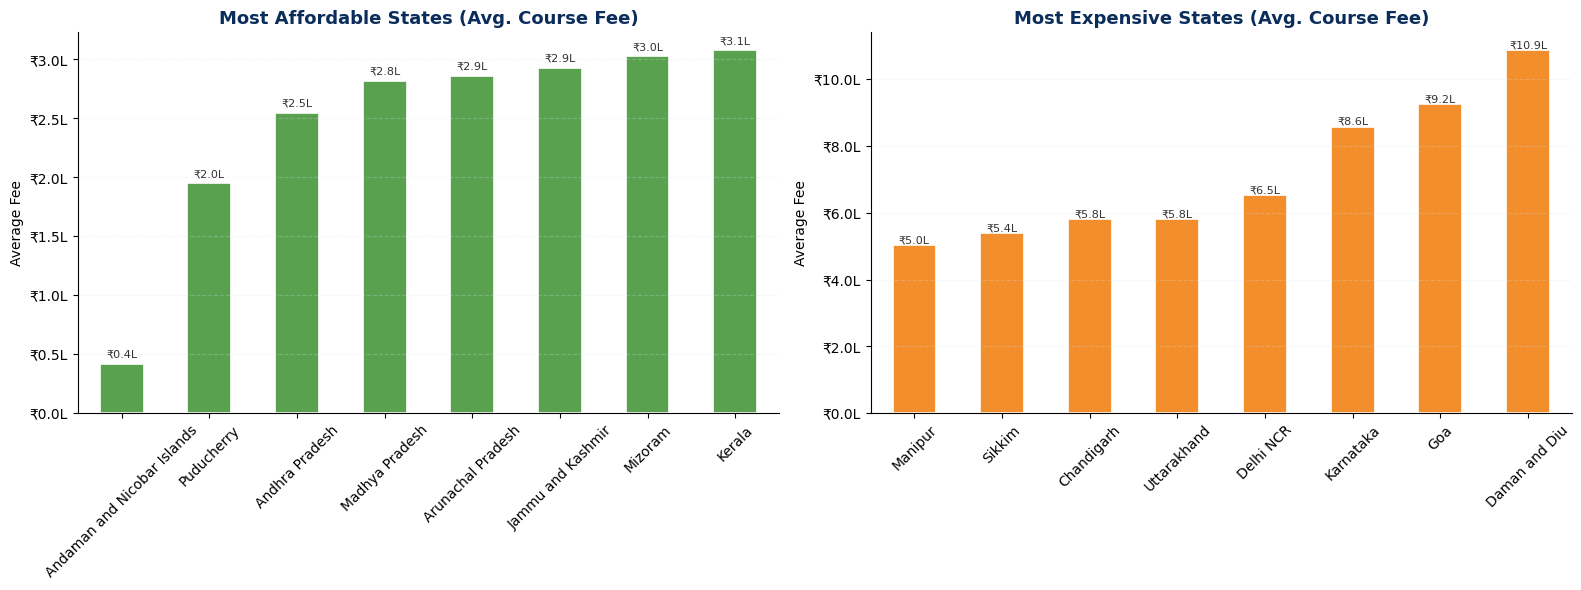

National avg fee: ₹4.41L
Cheapest state: Andaman and Nicobar Islands — ₹0.42L
Most expensive: Daman and Diu — ₹10.86L


In [85]:
# State-wise average fee

state_fee = df.groupby('State')['Course_Fee'].mean().sort_values()

# Theme colors
affordable_color = '#59A14F'   # Soft Emerald
expensive_color  = '#F28E2B'   # Coral Orange
grid_color       = '#D9E2EC'
title_color      = '#0B2D5B'

# Figure
fig, axes = plt.subplots(1, 2, figsize=(16,6))


# Affordable States

state_fee.head(8).plot(
    kind='bar',
    ax=axes[0],
    color=affordable_color,
    edgecolor='white',
    linewidth=1.2
)

axes[0].set_title(
    'Most Affordable States (Avg. Course Fee)',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[0].set_ylabel('Average Fee')
axes[0].set_xlabel('')

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L')
)

axes[0].tick_params(axis='x', rotation=45)

# Grid
axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.25,
    color=grid_color
)

# Value labels
for p in axes[0].patches:
    axes[0].annotate(
        f'₹{p.get_height()/100000:.1f}L',
        (p.get_x()+p.get_width()/2,
         p.get_height()+5000),
        ha='center',
        fontsize=8,
        color='#333333'
    )

# Remove borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Expensive States

state_fee.tail(8).plot(
    kind='bar',
    ax=axes[1],
    color=expensive_color,
    edgecolor='white',
    linewidth=1.2
)

axes[1].set_title(
    'Most Expensive States (Avg. Course Fee)',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[1].set_ylabel('Average Fee')
axes[1].set_xlabel('')

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L')
)

axes[1].tick_params(axis='x', rotation=45)

axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.25,
    color=grid_color
)

# Value labels
for p in axes[1].patches:
    axes[1].annotate(
        f'₹{p.get_height()/100000:.1f}L',
        (p.get_x()+p.get_width()/2,
         p.get_height()+5000),
        ha='center',
        fontsize=8,
        color='#333333'
    )

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Summary

print(f"National avg fee: ₹{state_fee.mean()/100000:.2f}L")
print(f"Cheapest state: {state_fee.index[0]} — ₹{state_fee.iloc[0]/100000:.2f}L")
print(f"Most expensive: {state_fee.index[-1]} — ₹{state_fee.iloc[-1]/100000:.2f}L")

## 📊 Finding 4.2 — Package Outcomes by State

### Top States by Average Package
| State | Avg Package | Highest Package |
|---|---|---|
| Daman & Diu | ₹12L | ₹57L |
| Goa | ₹10L | ₹29L |
| Tripura | ₹9.7L | ₹29L |
| Delhi NCR | ₹8.5L | ₹31L |
| Chandigarh | ₹7.5L | ₹34L |

### Key Observations

**The Average vs Highest gap is large everywhere.**
Every state shows a massive difference between
average and highest package — meaning strong
outcomes are concentrated in a few top colleges,
not spread across all institutions.

**Daman & Diu** shows the widest gap —
₹12L average but ₹57L highest.
Only 1 college — single data point,
not representative.

**Tripura** stands out — ₹9.7L average
with only 6 colleges. Strong outcome
relative to its size.

**States like Jharkhand, Karnataka,
Telangana, Uttar Pradesh** all cluster
around ₹5–6L average despite having
hundreds of colleges.

> The average package in most states
> sits between ₹5L–₹8L.
> The highest package in every state
> is 3x–5x the average — showing
> that top outcomes are the exception,
> not the norm.

**4.2 — The ROI Map: Where Is Your Money Best Spent?**

Which states give you the highest return on your fee investment? Which states are the worst value deals in Indian engineering?

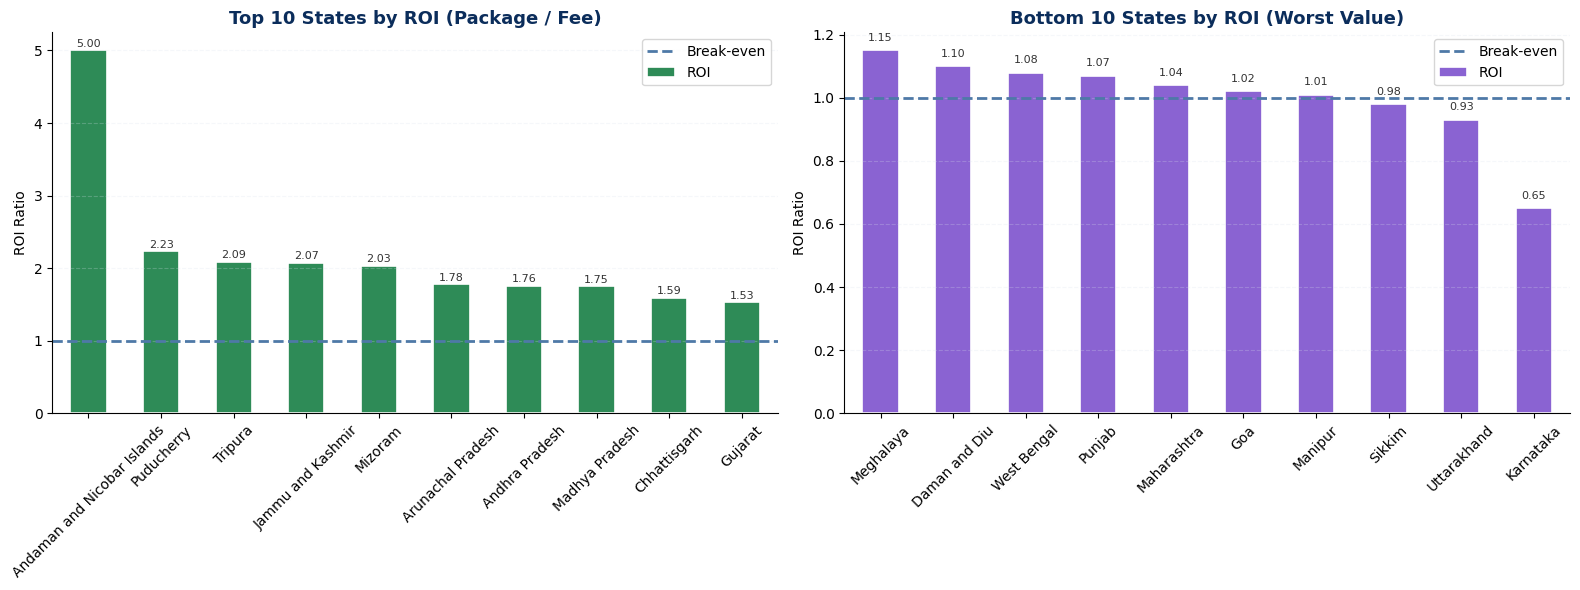

In [86]:
# ROI Calculation

state_roi = df.groupby('State').agg(
    Avg_Fee=('Course_Fee', 'mean'),
    Avg_Package=('Average_Package', 'mean')
)

state_roi['ROI'] = (
    state_roi['Avg_Package'] /
    state_roi['Avg_Fee']
).round(2).clip(upper=5)

state_roi = state_roi.sort_values('ROI', ascending=False)


# Theme Colors (Option 5)

best_color = '#2E8B57'        # Sea Green
worst_color = '#8A63D2'       # Lavender Purple
break_even_color = '#4E79A7' # Steel Blue
title_color = '#0B2D5B'      # Navy
grid_color = '#D9E2EC'
label_color = '#333333'


# Create Figure

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# LEFT PANEL : TOP 10 ROI STATES

state_roi['ROI'].head(10).plot(
    kind='bar',
    ax=axes[0],
    color=best_color,
    edgecolor='white',
    linewidth=1.2
)

axes[0].axhline(
    y=1.0,
    color=break_even_color,
    linestyle='--',
    linewidth=2,
    label='Break-even'
)

axes[0].set_title(
    'Top 10 States by ROI (Package / Fee)',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[0].set_ylabel('ROI Ratio')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Grid
axes[0].grid(
    axis='y',
    linestyle='--',
    alpha=0.25,
    color=grid_color
)

# Value labels
for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_height():.2f}',
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.05
        ),
        ha='center',
        fontsize=8,
        color=label_color
    )

# Remove borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[0].legend()

# RIGHT PANEL : BOTTOM 10 ROI STATES

state_roi['ROI'].tail(10).plot(
    kind='bar',
    ax=axes[1],
    color=worst_color,
    edgecolor='white',
    linewidth=1.2
)

axes[1].axhline(
    y=1.0,
    color=break_even_color,
    linestyle='--',
    linewidth=2,
    label='Break-even'
)

axes[1].set_title(
    'Bottom 10 States by ROI (Worst Value)',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[1].set_ylabel('ROI Ratio')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Grid
axes[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.25,
    color=grid_color
)

# Value labels
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.2f}',
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.03
        ),
        ha='center',
        fontsize=8,
        color=label_color
    )

# Remove borders
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[1].legend()

plt.tight_layout()
plt.show()

## 📊 Finding 4.2 — ROI: Where Does Your Fee Investment Pay Off?

### ROI = Average Package ÷ Average Course Fee

### Best Value States
| State | ROI |
|---|---|
| Andaman & Nicobar | 5.0x (capped) |
| Puducherry | 2.3x |
| Tripura | 2.1x |
| Jammu & Kashmir | 2.1x |
| Mizoram | 2.0x |
| Arunachal Pradesh | 1.8x |
| Andhra Pradesh | 1.8x |

### Worst Value States
| State | ROI |
|---|---|
| Karnataka | 0.65x |
| Uttarakhand | 0.94x |
| Sikkim | 0.98x |
| Manipur | 1.01x |
| Goa | 1.02x |
| Maharashtra | 1.03x |

### Key Observations

**Karnataka ROI is 0.65x** — the average
graduate earns less per year than the
total fee paid. Lowest ROI in the country.

**Sikkim and Uttarakhand are below 1x** —
fees exceed annual package on average.

**All bottom 10 states cluster between
0.65x–1.15x** — barely breaking even
or running at a loss.

**Andaman & Nicobar is capped at 5x** —
only 1 college, not a reliable benchmark.

> Every state in the bottom 10 is above
> the break-even line of ROI=1 except
> Karnataka, Sikkim and Uttarakhand —
> meaning in those 3 states, on average,
> the degree does not pay for itself
> in year one.


**4.3 — The Trap States: High Fee, Low Package**

Which states are charging above-average fees but delivering below-average outcomes — the worst deals in Indian engineering?

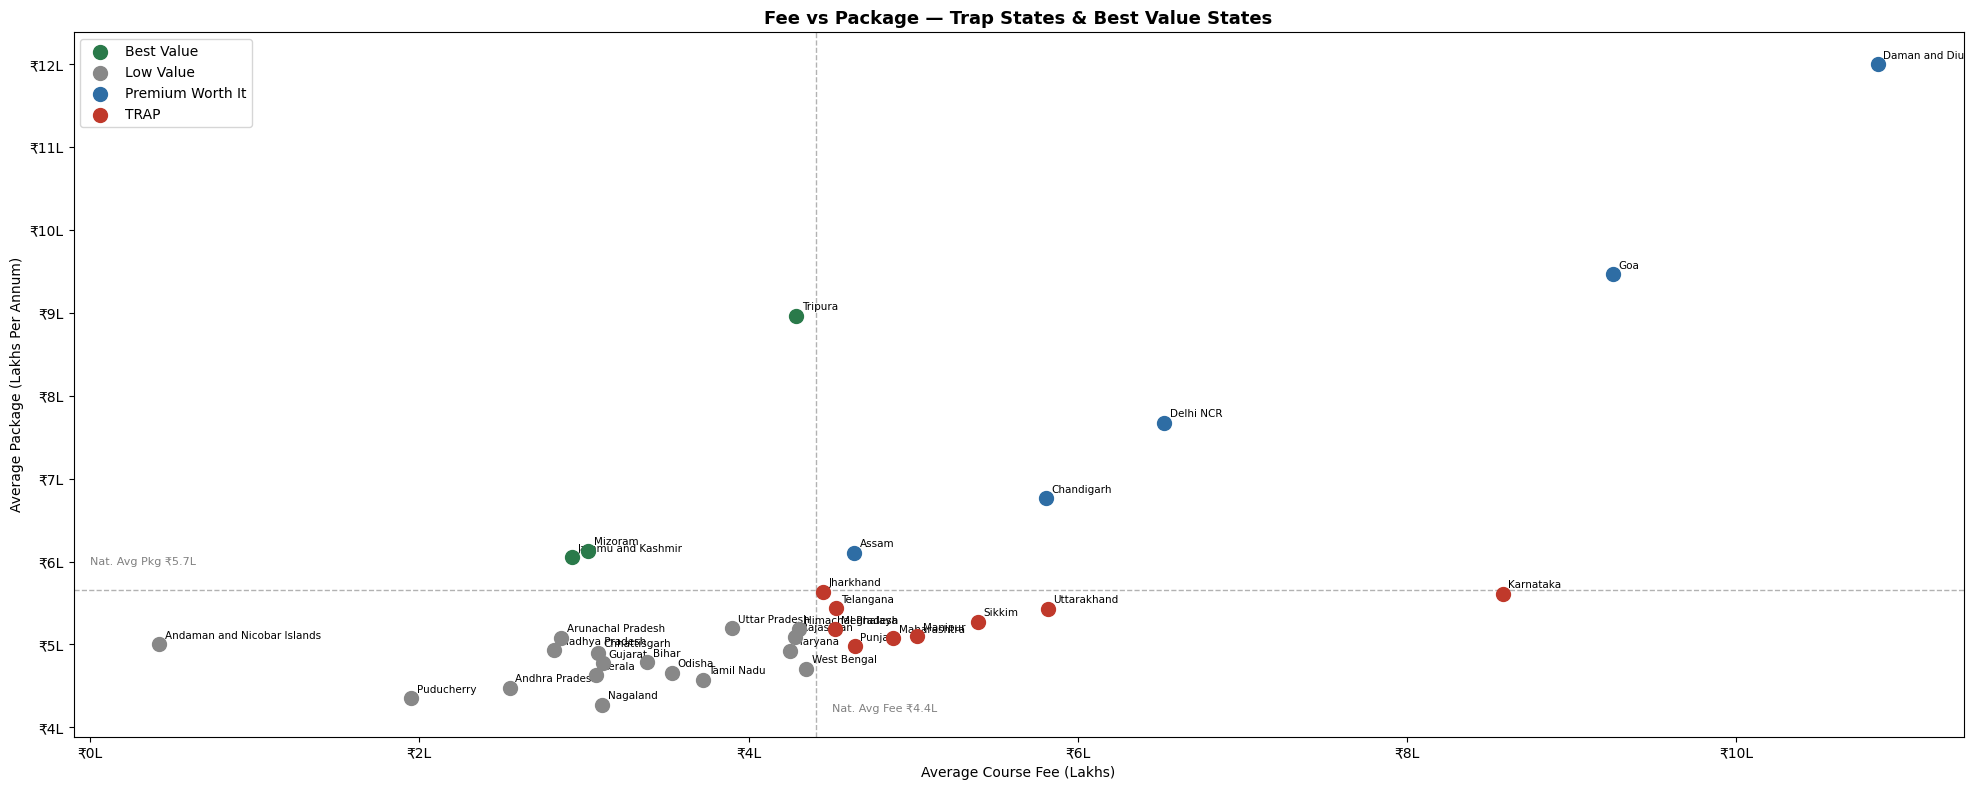

In [87]:
# Create State ROI dataframe

state_roi = df.groupby('State').agg(
    Avg_Fee=('Course_Fee', 'mean'),
    Avg_Package=('Average_Package', 'mean')
)

state_roi['ROI'] = (state_roi['Avg_Package'] / state_roi['Avg_Fee']).round(2).clip(upper=5)

# National averages
nat_avg_fee = state_roi['Avg_Fee'].mean()
nat_avg_pkg = state_roi['Avg_Package'].mean()

# Assign Quadrants

state_roi['Quadrant'] = 'Low Value'

state_roi.loc[
    (state_roi['Avg_Fee'] > nat_avg_fee) &
    (state_roi['Avg_Package'] > nat_avg_pkg),
    'Quadrant'
] = 'Premium Worth It'

state_roi.loc[
    (state_roi['Avg_Fee'] < nat_avg_fee) &
    (state_roi['Avg_Package'] > nat_avg_pkg),
    'Quadrant'
] = 'Best Value'

state_roi.loc[
    (state_roi['Avg_Fee'] > nat_avg_fee) &
    (state_roi['Avg_Package'] < nat_avg_pkg),
    'Quadrant'
] = 'TRAP'

fig, ax = plt.subplots(figsize=(20, 8))

colors = {
    'TRAP':             '#C0392B',
    'Best Value':       '#2A7A4A',
    'Premium Worth It': '#2E6DA4',
    'Low Value':        '#888888'
}

for quadrant, group in state_roi.groupby('Quadrant'):
    ax.scatter(group['Avg_Fee']/100000, group['Avg_Package']/100000,
               color=colors[quadrant], label=quadrant, s=100, zorder=5)
    for state, row in group.iterrows():
        ax.annotate(state, (row['Avg_Fee']/100000, row['Avg_Package']/100000),
                    fontsize=7.5, xytext=(4, 4), textcoords='offset points')

ax.axvline(nat_avg_fee/100000, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(nat_avg_pkg/100000, color='gray', linestyle='--', linewidth=1, alpha=0.6)

ax.text(nat_avg_fee/100000 + 0.1, ax.get_ylim()[0] + 0.3,
        f'Nat. Avg Fee ₹{nat_avg_fee/100000:.1f}L', fontsize=8, color='gray')
ax.text(ax.get_xlim()[0] + 0.1, nat_avg_pkg/100000 + 0.3,
        f'Nat. Avg Pkg ₹{nat_avg_pkg/100000:.1f}L', fontsize=8, color='gray')

ax.set_xlabel('Average Course Fee (Lakhs)')
ax.set_ylabel('Average Package (Lakhs Per Annum)')
ax.set_title('Fee vs Package — Trap States & Best Value States',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:.0f}L'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:.0f}L'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### 📊 Finding 4.3 — The Trap States Named and Shamed

From our analysis, the **TRAP states** — charging above-average fees but delivering below-average placement packages — are:

**Jharkhand, Telangana, Meghalaya, Punjab, Maharashtra, Manipur, Sikkim, Uttarakhand, Karnataka**

> Important caveat: For **Telangana and Maharashtra**, the "trap" classification at the state average level is heavily influenced by the sheer volume of mid-tier colleges. Both states have world-class institutions (IIT Hyderabad, BITS Pune, IIT Bombay) — but those are outliers, not the average experience.

> **Jharkhand** is the most concerning case: above-average fees, low packages, no AI/ML colleges, and a CSE monopoly of 74.5%. A student choosing Jharkhand for engineering faces a triple disadvantage.

# **The State Report Card — Final Rankings**

---
# 🏅 Chapter 5 — The State Report Card: Final Rankings

**Methodology:** Each state is scored on 5 equally important factors, normalized to 0–1:

| Factor | Weight | Why |
|---|---|---|
| Average Package | 30% | Primary outcome for students |
| ROI (Package/Fee) | 20% | Value per rupee spent |
| College Count | 20% | Access — are there options? |
| Student Rating | 15% | Ground-level quality perception |
| Accreditation Score | 15% | Regulatory compliance |

> States with fewer than 5 colleges are excluded from the final ranking to avoid small-sample distortions (e.g. a single highly-paid college making a union territory rank #1).


In [88]:
from sklearn.preprocessing import MinMaxScaler

# Ensure numeric accreditation
for col in ['AICTE_Approval','UGC_Recognition','NBA_Accreditation']:
    if df[col].dtype == object:
        df[col] = df[col].map({'Yes':1,'No':0,'Exempt':1}).fillna(0)

state_summary = df.groupby('State').agg(
    Average_Package=('Average_Package','mean'),
    Course_Fee=('Course_Fee','mean'),
    College_Count=('College Name','count'),
    Rating=('Rating','mean'),
    AICTE_Count=('AICTE_Approval','sum'),
    NBA_Count=('NBA_Accreditation','sum')
)
state_summary['ROI'] = (state_summary['Average_Package']/state_summary['Course_Fee']).clip(upper=5)
state_summary['Accreditation_Score'] = (
    (state_summary['AICTE_Count']+state_summary['NBA_Count'])/state_summary['College_Count'])

# Filter minimum 5 colleges for a fair ranking
state_summary = state_summary[state_summary['College_Count'] >= 5]

scaler = MinMaxScaler()
cols = ['Average_Package','ROI','College_Count','Rating','Accreditation_Score']
state_summary[[c+'_norm' for c in cols]] = scaler.fit_transform(state_summary[cols])

state_summary['Final_Score'] = (
    state_summary['Average_Package_norm'] * 0.30 +
    state_summary['ROI_norm']             * 0.20 +
    state_summary['College_Count_norm']   * 0.20 +
    state_summary['Rating_norm']          * 0.15 +
    state_summary['Accreditation_Score_norm'] * 0.15)

state_summary = state_summary.sort_values('Final_Score', ascending=False)
state_summary['Rank'] = range(1, len(state_summary)+1)
print(f"States ranked: {len(state_summary)}")
print(state_summary[['College_Count','Average_Package','ROI','Rating','Final_Score','Rank']].head(10).to_string())

States ranked: 30
                   College_Count  Average_Package       ROI    Rating  Final_Score  Rank
State                                                                                   
Tripura                        6    896833.333333  2.090058  3.816667     0.691866     1
Tamil Nadu                   612    457193.723856  1.228347  3.742974     0.502027     2
Goa                            9    946444.444444  1.023230  3.777778     0.497368     3
Andhra Pradesh               304    447610.898026  1.755563  3.769408     0.481959     4
Telangana                    212    543550.415094  1.200140  3.830660     0.462618     5
Uttar Pradesh                420    519707.252381  1.331988  3.734048     0.458663     6
Maharashtra                  491    507743.057026  1.040724  3.741344     0.454098     7
Delhi NCR                     58    767637.931034  1.176092  3.789655     0.434945     8
Jammu and Kashmir             19    605315.789474  2.066150  3.631579     0.420620     9
Mad

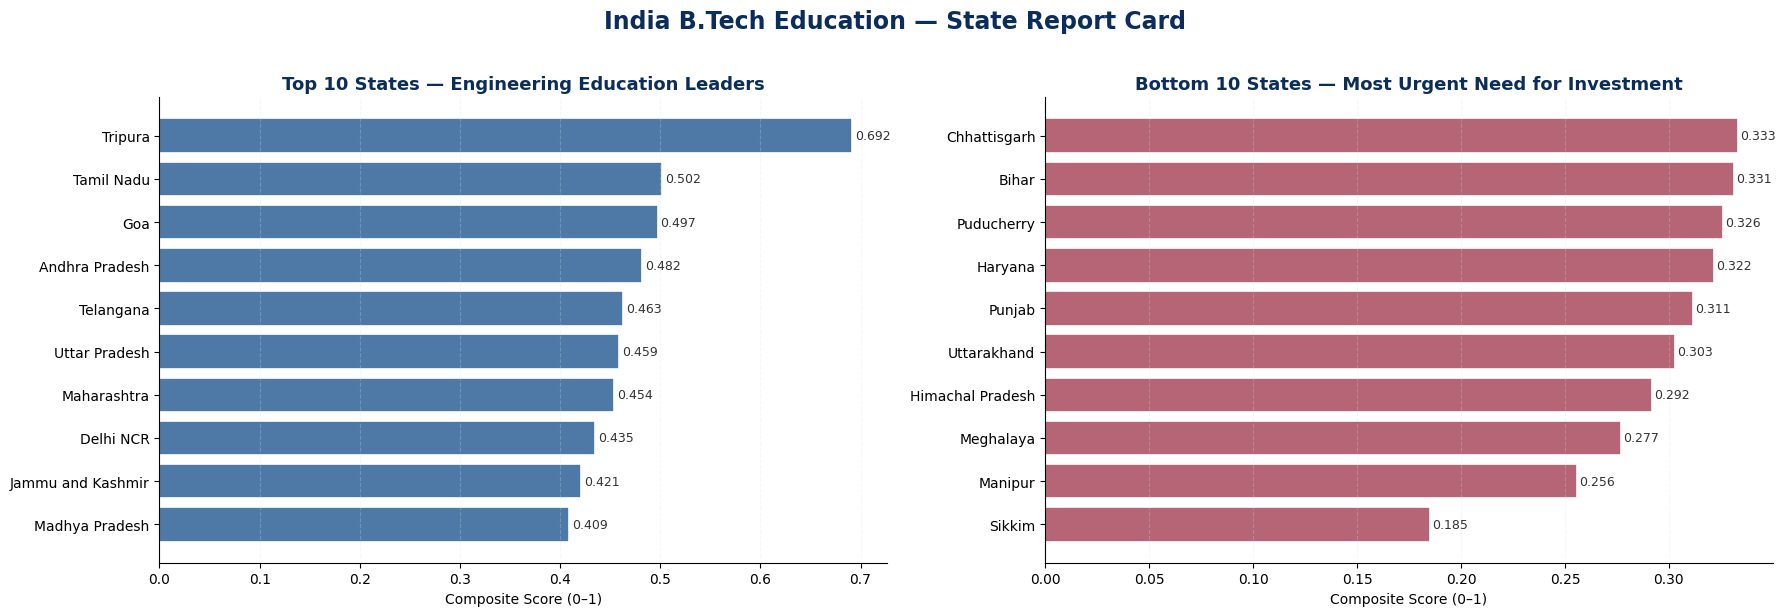

In [89]:
# Theme Colors

leader_color = '#4E79A7'    # Steel Blue
laggard_color = '#B56576'   # Dusty Wine Red
title_color = '#0B2D5B'     # Navy Blue
grid_color = '#D9E2EC'
label_color = '#333333'

# Create Figure

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# TOP 10 STATES

top10 = state_summary.head(10)

bars1 = axes[0].barh(
    top10.index[::-1],
    top10['Final_Score'][::-1],
    color=leader_color,
    edgecolor='white',
    linewidth=1.2
)

axes[0].set_title(
    'Top 10 States — Engineering Education Leaders',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[0].set_xlabel('Composite Score (0–1)')
axes[0].grid(
    axis='x',
    linestyle='--',
    alpha=0.25,
    color=grid_color
)

# Value labels
for i, (idx, row) in enumerate(top10[::-1].iterrows()):
    axes[0].text(
        row['Final_Score'] + 0.003,
        i,
        f'{row["Final_Score"]:.3f}',
        va='center',
        fontsize=9,
        color=label_color
    )

# Clean look
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# BOTTOM 10 STATES

bot10 = state_summary.tail(10)

bars2 = axes[1].barh(
    bot10.index[::-1],
    bot10['Final_Score'][::-1],
    color=laggard_color,
    edgecolor='white',
    linewidth=1.2
)

axes[1].set_title(
    'Bottom 10 States — Most Urgent Need for Investment',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[1].set_xlabel('Composite Score (0–1)')
axes[1].grid(
    axis='x',
    linestyle='--',
    alpha=0.25,
    color=grid_color
)

# Value labels
for i, (idx, row) in enumerate(bot10[::-1].iterrows()):
    axes[1].text(
        row['Final_Score'] + 0.001,
        i,
        f'{row["Final_Score"]:.3f}',
        va='center',
        fontsize=9,
        color=label_color
    )

# Clean look
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# MAIN TITLE

plt.suptitle(
    'India B.Tech Education — State Report Card',
    fontsize=17,
    fontweight='bold',
    color=title_color,
    y=1.02
)

plt.tight_layout()
plt.show()

#**State Profile Cards**

In [90]:
def state_profile(state_name):
    row = state_summary.loc[state_name]
    branches = branch_state.loc[state_name] if state_name in branch_state.index else pd.Series()
    top_br = branches[branches>0].sort_values(ascending=False).head(5).index.tolist() if len(branches) else []
    sc = state_counts.get(state_name, 0)
    print(f"{'='*52}")
    print(f"  {state_name.upper()}  —  Rank #{int(row['Rank'])}")
    print(f"{'='*52}")
    print(f"  Composite Score   : {row['Final_Score']:.3f}")
    print(f"  Colleges          : {int(row['College_Count'])}")
    print(f"  Avg Package       : ₹{row['Average_Package']/100000:.2f}L per annum")
    print(f"  Avg Course Fee    : ₹{row['Course_Fee']/100000:.2f}L total")
    print(f"  ROI               : {row['ROI']:.2f}x")
    print(f"  Student Rating    : {row['Rating']:.2f} / 5.0")
    print(f"  Top Branches      : {' | '.join(top_br) if top_br else 'N/A'}")
    print()

print("🏆 TOP 5 STATES — Where to Study Engineering in India")
print()
for s in state_summary.head(5).index:
    state_profile(s)

print()
print("⚠️  BOTTOM 5 STATES — Most Urgent Need for Policy Attention")
print()
for s in state_summary.tail(5).index:
    state_profile(s)


🏆 TOP 5 STATES — Where to Study Engineering in India

  TRIPURA  —  Rank #1
  Composite Score   : 0.692
  Colleges          : 6
  Avg Package       : ₹8.97L per annum
  Avg Course Fee    : ₹4.29L total
  ROI               : 2.09x
  Student Rating    : 3.82 / 5.0
  Top Branches      : CSE | Mechanical | Other

  TAMIL NADU  —  Rank #2
  Composite Score   : 0.502
  Colleges          : 612
  Avg Package       : ₹4.57L per annum
  Avg Course Fee    : ₹3.72L total
  ROI               : 1.23x
  Student Rating    : 3.74 / 5.0
  Top Branches      : CSE | ECE | AI / Data Science | IT | Mechanical

  GOA  —  Rank #3
  Composite Score   : 0.497
  Colleges          : 9
  Avg Package       : ₹9.46L per annum
  Avg Course Fee    : ₹9.25L total
  ROI               : 1.02x
  Student Rating    : 3.78 / 5.0
  Top Branches      : CSE | Aerospace | Civil

  ANDHRA PRADESH  —  Rank #4
  Composite Score   : 0.482
  Colleges          : 304
  Avg Package       : ₹4.48L per annum
  Avg Course Fee    : ₹2.55L t

#### 📊 Finding 5 — The State Report Card Results

**Top performers** (Tamil Nadu, Maharashtra, Uttar Pradesh, Karnataka, Andhra Pradesh) win on a combination of volume, accreditation, and package outcomes.

**Bottom performers** are almost entirely Northeast states and small union territories — not because of any failure of effort, but because they simply have fewer institutions, less industry nearby, and less historical investment.

> **The Tripura surprise:** Tripura's high ROI (2.09x) despite only 6 colleges suggests its small number of colleges are actually quite good relative to their fees. This is a hidden gem that no standard ranking would surface.

# **Conclusions & Policy Recommendations**

---
# 📋 Chapter 6 — Conclusions & Policy Recommendations

## The 5 Key Findings from This Analysis

| # | Finding | The Number |
|---|---|---|
| F1 | **Access Inequality** | Top 3 states hold 36% of all colleges. Bottom 10 states share just 5%. |
| F2 | **Elite Institution Gap** | 20+ states have zero IITs or NITs. Students must leave their state for premier education. |
| F3 | **The CSE Monoculture** | 21 of 34 states have CSE occupying >60% of all college offerings. |
| F4 | **The Future-Tech Divide** | 14 states have zero AI/ML, Data Science, or Cyber Security colleges. |
| F5 | **The Trap States** | 9 states charge above-average fees but deliver below-average packages — including Jharkhand, Punjab, and Uttarakhand. |

---

## Recommendations

### 🎓 For Students & Families
- **Best value states:** Tamil Nadu and Uttar Pradesh offer the best combination of choice, affordability, and outcomes for most students
- **Best ROI:** Tripura (2.09x) and Uttar Pradesh (1.33x) deliver more package per rupee of fees
- **Avoid the trap:** Think carefully before paying premium fees in Uttarakhand, Sikkim, or Karnataka's mid-tier private colleges — the average outcome does not justify the cost
- **Future-tech seekers:** If AI/ML is your goal, you need to target Maharashtra, Tamil Nadu, or Delhi NCR — 14 states simply don't offer this pathway

### 🏛️ For State Governments
- **Northeast states** need minimum one IIT or NIT equivalent — the current complete absence of premier institutions in this region is the single biggest equity failure in Indian engineering education
- **CSE monopoly states** should incentivize branch diversification: offer land grants, faculty hiring subsidies, or fee waivers for new Aerospace, Biotech, and Robotics programs
- **Trap states** need outcome accountability: link college affiliation renewal to placement performance, not just infrastructure checklists

### 📋 For AICTE & Policy Bodies
- The AI/ML gap in 14 states is not a market failure — markets would provide these programs if demand existed. It is a **capacity and awareness gap** that requires direct intervention
- A **National Course Diversity Index** should be published annually, tracking branch diversity by state the same way NIRF tracks institutional rankings
- Accreditation should be tied to outcome data (placement rates, salary surveys) — not just input metrics (labs, faculty ratios)

---

## Closing Statement

> *A student born in Bihar shouldn't have fewer engineering options than one born in Maharashtra. A family in Nagaland shouldn't pay the same fees for a fraction of the job opportunities available to a student in Bengaluru.*
>
> *This analysis does not solve these inequalities — but it names them, measures them, and shows exactly where intervention is most needed. The data is on the table. The gaps are visible. The next step belongs to the people who have the power to close them.*

In [91]:
Thank you

SyntaxError: invalid syntax (2169910179.py, line 1)